# A02 — Explainability, Failure Analysis, and Bias Evaluation

**EEEM068 Applied Machine Learning — Explainability and Failure-Mode Analysis (no training)**

**Objective:** explain model behaviour, identify common failure patterns, and evaluate
whether performance changes across important image-quality and patient-related subgroups.

**A02 does not retrain any model and does not tune anything.** It loads frozen checkpoints
and A01's saved test predictions, probabilities, and labels. No threshold, ensemble weight,
or temperature is changed anywhere in this notebook.

**Headline systems:** EfficientNet-B4 (Exp01), DeiT-III (D07), MaxViT-Tiny M12, and the
M13-D ensemble. M12 is the primary final model under A01's predefined QWK-first hierarchy.
M13-D is retained as a complementary ensemble because it has slightly better macro-F1 and
calibration, but lower QWK and greater computational complexity.

**Scientific wording rules**

Do not claim that a heatmap detects or proves a clinical lesion. Grad-CAM and attention
rollout are qualitative model-sensitivity or attention visualisations. They may indicate
regions associated with a prediction, but lesion-level annotations are not available for
clinical localisation validation.

**Implementation safeguards:** frozen checkpoints and frozen A01 outputs only; no training,
threshold tuning, temperature fitting, or ensemble-weight selection. Report figures are
saved as high-resolution PNG files and, where appropriate, vector PDF files.


In [1]:
import json
import random
from pathlib import Path
from itertools import combinations

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    f1_score,
    log_loss,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

NUM_CLASSES = 5
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

PROJECT_ROOT = Path(
    "/scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Seed: {SEED}")
print(f"CLASS_NAMES: {CLASS_NAMES}")

Device: cuda
Seed: 42
CLASS_NAMES: ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']


In [2]:
A02_LOG_DIR = PROJECT_ROOT / "logs" / "analysis" / "A02_explainability_failure_analysis"
A02_FIGURE_DIR = PROJECT_ROOT / "results" / "figures" / "analysis" / "A02_explainability_failure_analysis"
for sub in ["efficientnet", "deit", "m12"]:
    (A02_FIGURE_DIR / sub).mkdir(parents=True, exist_ok=True)
A02_LOG_DIR.mkdir(parents=True, exist_ok=True)

A01_LOG_DIR = PROJECT_ROOT / "logs" / "analysis" / "A01_final_model_comparison"
TEST_CSV = PROJECT_ROOT / "configs" / "splits" / "internal_test_split.csv"

FROZEN_CHECKPOINTS = {
    "EfficientNet-B4": PROJECT_ROOT / "checkpoints" / "efficientnet_b4" / "exp01_shared_p0_wrs_focal_seed42" / "best_model.pt",
    "DeiT-III": PROJECT_ROOT / "checkpoints" / "deit3_b16" / "D07_two_phase_finetuning" / "best.pt",
    "M09": PROJECT_ROOT / "checkpoints" / "maxvit_tiny" / "M09_detection_guided_regions" / "best.pt",
    "M10": PROJECT_ROOT / "checkpoints" / "maxvit_tiny" / "M10_pseudo_segmentation_guidance" / "best.pt",
    "M11": PROJECT_ROOT / "checkpoints" / "maxvit_tiny" / "M11_global_local_crop_fusion" / "best.pt",
    "M12": PROJECT_ROOT / "checkpoints" / "maxvit_tiny" / "M12_combined_fine_grained_guidance" / "best.pt",
}
FROZEN_CONFIG_DIRS = {
    "M07": PROJECT_ROOT / "logs" / "maxvit_tiny" / "M07_ordinal_aware_loss",
    "M09": PROJECT_ROOT / "logs" / "maxvit_tiny" / "M09_detection_guided_regions",
    "M10": PROJECT_ROOT / "logs" / "maxvit_tiny" / "M10_pseudo_segmentation_guidance",
    "M11": PROJECT_ROOT / "logs" / "maxvit_tiny" / "M11_global_local_crop_fusion",
    "M12": PROJECT_ROOT / "logs" / "maxvit_tiny" / "M12_combined_fine_grained_guidance",
}
M13_LOG_DIR = PROJECT_ROOT / "logs" / "maxvit_tiny" / "M13_calibrated_class_specialist_ensemble"

print(f"A02 logs    -> {A02_LOG_DIR}")
print(f"A02 figures -> {A02_FIGURE_DIR}")
print(f"A01 logs (read-only) -> {A01_LOG_DIR}")

A02 logs    -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/analysis/A02_explainability_failure_analysis
A02 figures -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis
A01 logs (read-only) -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/analysis/A01_final_model_comparison


In [3]:
test_df = pd.read_csv(TEST_CSV)
test_df["image"] = test_df["image"].astype(str)

a01_predictions = {}
for model_name, csv_name in [
    ("EfficientNet-B4", PROJECT_ROOT / "logs" / "efficientnet_b4" / "exp01_shared_p0_wrs_focal_seed42" / "A01_frozen_test_predictions" / "test_predictions.csv"),
    ("DeiT-III", PROJECT_ROOT / "logs" / "deit3_b16" / "D07_two_phase_finetuning" / "A01_frozen_test_predictions" / "test_predictions.csv"),
    ("M12", PROJECT_ROOT / "logs" / "maxvit_tiny" / "M12_combined_fine_grained_guidance" / "A01_frozen_test_predictions" / "test_predictions.csv"),
]:
    if not csv_name.exists():
        raise FileNotFoundError(
            f"A01's frozen test predictions for {model_name} not found at {csv_name}. "
            "A02 reads A01's already-saved outputs and does not run inference itself for "
            "the headline metrics - run A01 first."
        )
    a01_predictions[model_name] = pd.read_csv(csv_name)

m13_test_predictions_path = PROJECT_ROOT / "logs" / "analysis" / "A01_final_model_comparison" / "m13_test_predictions.csv"
if not m13_test_predictions_path.exists():
    raise FileNotFoundError(f"A01's m13_test_predictions.csv not found at {m13_test_predictions_path}. Run A01 first.")
a01_predictions["M13-D"] = pd.read_csv(m13_test_predictions_path)

for model_name, df in a01_predictions.items():
    id_col = "image_id" if "image_id" in df.columns else "image"
    if id_col != "image_id":
        df.rename(columns={id_col: "image_id"}, inplace=True)
    df["image_id"] = df["image_id"].astype(str)

print("Loaded A01 frozen test predictions for:", list(a01_predictions.keys()))
for model_name, df in a01_predictions.items():
    print(f"  {model_name}: {len(df):,} rows")

Loaded A01 frozen test predictions for: ['EfficientNet-B4', 'DeiT-III', 'M12', 'M13-D']
  EfficientNet-B4: 5,270 rows
  DeiT-III: 5,270 rows
  M12: 5,270 rows
  M13-D: 5,270 rows


In [4]:
reference_ids = set(a01_predictions["M12"]["image_id"])
for model_name, df in a01_predictions.items():
    model_ids = set(df["image_id"])
    assert model_ids == reference_ids, f"{model_name}'s A01 test image IDs do not match the reference set."
    assert df["image_id"].is_unique, f"{model_name} has duplicate image IDs in its A01 predictions."

# Confirm every model's row order (once re-indexed by image_id) reflects the same underlying
# label per image, i.e. A01's outputs are internally consistent.
label_col_by_model = {}
for model_name, df in a01_predictions.items():
    label_col = "true_label" if "true_label" in df.columns else "true_grade"
    label_col_by_model[model_name] = label_col
reference_labels = a01_predictions["M12"].set_index("image_id")[label_col_by_model["M12"]].to_dict()
for model_name, df in a01_predictions.items():
    model_labels = df.set_index("image_id")[label_col_by_model[model_name]].to_dict()
    assert all(model_labels[image_id] == reference_labels[image_id] for image_id in reference_ids), (
        f"{model_name}'s labels disagree with the reference for at least one image."
    )

print("All models use the same test images: PASSED")
print("Image labels agree across all A01 outputs: PASSED")
print("No training occurs in A02: guaranteed by construction (A02 only loads frozen checkpoints/configs).")
print("No thresholds or weights are changed: guaranteed by construction (no fitting/optimisation code in A02).")

with open(M13_LOG_DIR / "model_temperatures.json") as f:
    m13_frozen_temperatures = json.load(f)
m13_frozen_class_weights = pd.read_csv(M13_LOG_DIR / "class_specialist_weights.csv", index_col=0)
with open(M13_LOG_DIR / "final_ensemble_config.json") as f:
    m13_frozen_config = json.load(f)

print(f"\nM13-D frozen temperatures (loaded, never refit here): {m13_frozen_temperatures}")
print("M13-D weights and temperatures remain frozen: PASSED (loaded read-only from M13's saved files)")

All models use the same test images: PASSED
Image labels agree across all A01 outputs: PASSED
No training occurs in A02: guaranteed by construction (A02 only loads frozen checkpoints/configs).
No thresholds or weights are changed: guaranteed by construction (no fitting/optimisation code in A02).

M13-D frozen temperatures (loaded, never refit here): {'EfficientNet-B4': 0.5668804534855836, 'DeiT-III': 0.660285636646945, 'M07': 1.0107263921916896, 'M09': 1.0177247828675966, 'M10': 1.0135084300471375, 'M11': 1.4128051644889343, 'M12': 0.8952089177782394}
M13-D weights and temperatures remain frozen: PASSED (loaded read-only from M13's saved files)


## 2. Deterministic sample manifest

Examples are selected **deterministically, by a fixed rule and a fixed seed** — never
manually after looking at which heatmaps happen to look attractive. Around 5-10 images per
category, drawn from M12 (the primary final model) unless the category is inherently
comparative (e.g. M13-D vs M12).

**Cross-model comparison rule:** M12 defines the deterministic shared image sample, but
each figure reports the displayed model's own frozen prediction, confidence and correctness.


In [5]:
N_PER_CATEGORY = 8
rng = np.random.default_rng(SEED)

m12_df = a01_predictions["M12"].copy()
m12_df["confidence"] = m12_df[[f"prob_grade_{c}" for c in range(NUM_CLASSES)]].max(axis=1) if "prob_grade_0" in m12_df.columns else m12_df["confidence"]
m12_df["correct"] = m12_df["predicted_label"] == m12_df["true_label"]

m13_df = a01_predictions["M13-D"].copy()
prob_cols_m13 = [c for c in m13_df.columns if c.startswith("prob_")]
m13_df["confidence"] = m13_df[prob_cols_m13].max(axis=1)
m13_df["correct"] = m13_df["predicted_label"] == m13_df["true_label"]

merged_m12_m13 = m12_df[["image_id", "true_label", "predicted_label", "confidence", "correct"]].merge(
    m13_df[["image_id", "predicted_label", "confidence", "correct"]], on="image_id", suffixes=("_m12", "_m13"),
)

headline_correct = {
    name: (df["predicted_label"] == df["true_label"]) for name, df in a01_predictions.items()
}
all_headline_wrong_ids = set(m12_df["image_id"])
for name in a01_predictions:
    wrong_ids = set(a01_predictions[name].loc[~headline_correct[name], "image_id"])
    all_headline_wrong_ids &= wrong_ids


def sample_deterministic(pool_df: pd.DataFrame, n: int, category: str) -> pd.DataFrame:
    if len(pool_df) == 0:
        return pool_df
    n = min(n, len(pool_df))
    sampled = pool_df.sample(n=n, random_state=SEED)
    sampled = sampled.copy()
    sampled["selection_category"] = category
    sampled["selection_rank"] = range(1, len(sampled) + 1)
    return sampled


manifest_parts = []

manifest_parts.append(sample_deterministic(
    m12_df[m12_df["correct"] & (m12_df["confidence"] >= 0.80)], N_PER_CATEGORY, "correct_high_confidence"
))
manifest_parts.append(sample_deterministic(
    m12_df[m12_df["correct"] & (m12_df["confidence"] < 0.60)], N_PER_CATEGORY, "correct_low_confidence"
))
manifest_parts.append(sample_deterministic(
    m12_df[~m12_df["correct"] & (m12_df["confidence"] >= 0.80)], N_PER_CATEGORY, "high_confidence_incorrect"
))
manifest_parts.append(sample_deterministic(
    m12_df[(m12_df["true_label"] == 1) & (m12_df["predicted_label"] == 0)], N_PER_CATEGORY, "mild_predicted_as_no_dr"
))
manifest_parts.append(sample_deterministic(
    m12_df[(m12_df["true_label"] == 3) & (m12_df["predicted_label"] == 2)], N_PER_CATEGORY, "severe_predicted_as_moderate"
))
manifest_parts.append(sample_deterministic(
    m12_df[(m12_df["true_label"] == 4) & (m12_df["predicted_label"] == 2)], N_PER_CATEGORY, "pdr_predicted_as_moderate"
))
manifest_parts.append(sample_deterministic(
    m12_df[(m12_df["predicted_label"] - m12_df["true_label"]).abs() >= 2], N_PER_CATEGORY, "errors_two_or_more_grades"
))

m13_corrected_from_m12 = merged_m12_m13[(~merged_m12_m13["correct_m12"]) & (merged_m12_m13["correct_m13"])]
manifest_parts.append(sample_deterministic(
    m13_corrected_from_m12.merge(m12_df[["image_id", "true_label"]], on="image_id", suffixes=("", "_dup"))
    .rename(columns={"predicted_label_m13": "predicted_label", "confidence_m13": "confidence"}),
    N_PER_CATEGORY, "m13_corrected_from_m12",
))

m13_introduced_vs_m12 = merged_m12_m13[(merged_m12_m13["correct_m12"]) & (~merged_m12_m13["correct_m13"])]
manifest_parts.append(sample_deterministic(
    m13_introduced_vs_m12.merge(m12_df[["image_id", "true_label"]], on="image_id", suffixes=("", "_dup"))
    .rename(columns={"predicted_label_m13": "predicted_label", "confidence_m13": "confidence"}),
    N_PER_CATEGORY, "m13_introduced_vs_m12",
))

all_wrong_pool = m12_df[m12_df["image_id"].isin(all_headline_wrong_ids)]
manifest_parts.append(sample_deterministic(all_wrong_pool, N_PER_CATEGORY, "all_headline_models_wrong"))

sample_manifest_rows = []
for part in manifest_parts:
    if len(part) == 0:
        continue
    for _, row in part.iterrows():
        sample_manifest_rows.append({
            "image_id": row["image_id"],
            "true_label": int(row["true_label"]),
            "predicted_label": int(row["predicted_label"]),
            "confidence": float(row["confidence"]),
            "model": "M12" if row["selection_category"] not in ("m13_corrected_from_m12", "m13_introduced_vs_m12") else "M13-D",
            "selection_category": row["selection_category"],
            "selection_rank": int(row["selection_rank"]),
        })

sample_manifest_df = pd.DataFrame(sample_manifest_rows)
print(sample_manifest_df.groupby("selection_category").size())

sample_manifest_df.to_csv(A02_LOG_DIR / "sample_manifest.csv", index=False)
print(f"\nSaved -> {A02_LOG_DIR / 'sample_manifest.csv'}  ({len(sample_manifest_df)} rows)")

selection_category
all_headline_models_wrong       8
correct_high_confidence         8
correct_low_confidence          8
errors_two_or_more_grades       8
high_confidence_incorrect       8
m13_corrected_from_m12          8
m13_introduced_vs_m12           8
mild_predicted_as_no_dr         8
pdr_predicted_as_moderate       8
severe_predicted_as_moderate    8
dtype: int64

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/analysis/A02_explainability_failure_analysis/sample_manifest.csv  (80 rows)


## Shared P0 preprocessing

Identical to every prior notebook's crop/pad pipeline.

In [6]:
def preprocess_p0(image_path, target_size):
    img_bgr = cv2.imread(str(image_path))
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
        margin = int(min(w, h) * 0.02)
        x, y = max(0, x - margin), max(0, y - margin)
        w = min(img.shape[1] - x, w + 2 * margin)
        h = min(img.shape[0] - y, h + 2 * margin)
        img = img[y:y + h, x:x + w]
    h, w = img.shape[:2]
    side = max(h, w)
    canvas = np.zeros((side, side, 3), dtype=img.dtype)
    canvas[(side - h) // 2:(side - h) // 2 + h, (side - w) // 2:(side - w) // 2 + w] = img
    return cv2.resize(canvas, (target_size, target_size), interpolation=cv2.INTER_AREA)


def normalise_to_tensor(img_224, mean, std):
    import torchvision.transforms.functional as TF
    from PIL import Image
    return TF.normalize(TF.to_tensor(Image.fromarray(img_224)), mean=list(mean), std=list(std))


VIT_MEAN = (0.485, 0.456, 0.406)
VIT_STD = (0.229, 0.224, 0.225)
print("Shared P0 preprocessing ready.")

Shared P0 preprocessing ready.


## 3. EfficientNet explainability

Grad-CAM targeting the final convolutional feature layer (`conv_head`, immediately before
global pooling) — a standard hook-based implementation, not an approximation.

In [7]:
import timm

efficientnet_checkpoint = torch.load(FROZEN_CHECKPOINTS["EfficientNet-B4"], map_location=device, weights_only=False)
efficientnet_state_dict = efficientnet_checkpoint["model_state"] if "model_state" in efficientnet_checkpoint else efficientnet_checkpoint

efficientnet_backbone = timm.create_model("efficientnet_b4", pretrained=False, num_classes=0, global_pool="avg")
efficientnet_feature_dim = efficientnet_backbone.num_features
efficientnet_backbone.custom_head = nn.Sequential(
    nn.LayerNorm(efficientnet_feature_dim), nn.Dropout(p=0.3), nn.Linear(efficientnet_feature_dim, NUM_CLASSES),
)
_efficientnet_original_forward = efficientnet_backbone.forward

def _efficientnet_forward(images):
    features = _efficientnet_original_forward(images)
    return efficientnet_backbone.custom_head(features)

efficientnet_backbone.forward = _efficientnet_forward
efficientnet_backbone = efficientnet_backbone.to(device)
efficientnet_backbone.load_state_dict(efficientnet_state_dict, strict=True)
efficientnet_backbone.eval()
print("EfficientNet-B4: frozen checkpoint loaded for Grad-CAM (identical architecture to A01).")

EfficientNet-B4: frozen checkpoint loaded for Grad-CAM (identical architecture to A01).


In [8]:
class GradCAM:
    """Standard hook-based Grad-CAM: forward hook captures the target layer's activations,
    backward hook captures the gradient of the target class score w.r.t. those activations.
    CAM = ReLU(sum_channels(global-average-pooled gradient * activation))."""

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, input_tensor: torch.Tensor, class_idx: int) -> np.ndarray:
        self.model.zero_grad(set_to_none=True)
        logits = self.model(input_tensor)
        score = logits[0, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam


efficientnet_gradcam = GradCAM(efficientnet_backbone, efficientnet_backbone.conv_head)
print("Grad-CAM hooks attached to EfficientNet-B4's conv_head (final convolutional feature layer).")

Grad-CAM hooks attached to EfficientNet-B4's conv_head (final convolutional feature layer).


In [9]:
def overlay_heatmap(rgb_224: np.ndarray, cam: np.ndarray) -> np.ndarray:
    cam_resized = cv2.resize(cam, (rgb_224.shape[1], rgb_224.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(rgb_224, 0.55, heatmap, 0.45, 0)


efficientnet_manifest_rows = sample_manifest_df[sample_manifest_df["model"] == "M12"].copy()
efficientnet_explanations = []

for _, row in efficientnet_manifest_rows.iterrows():
    image_id = row["image_id"]
    filepath = test_df.set_index("image").loc[image_id, "filepath"]
    rgb_224 = preprocess_p0(filepath, 224)
    tensor = normalise_to_tensor(rgb_224, VIT_MEAN, VIT_STD).unsqueeze(0).to(device)
    tensor.requires_grad_(False)

    with torch.no_grad():
        eff_logits = efficientnet_backbone(tensor)
        eff_probs = F.softmax(eff_logits, dim=1)[0]
        eff_pred = int(eff_probs.argmax())
        eff_conf = float(eff_probs.max())

    cam = efficientnet_gradcam(tensor, eff_pred)
    overlay = overlay_heatmap(rgb_224, cam)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
    axes[0].imshow(rgb_224); axes[0].set_title("Original", fontsize=10)
    axes[1].imshow(cam, cmap="jet"); axes[1].set_title("Grad-CAM heatmap", fontsize=10)
    axes[2].imshow(overlay); axes[2].set_title("Overlay", fontsize=10)
    for ax in axes:
        ax.axis("off")
    fig.suptitle(
        f"EfficientNet-B4 | {row['selection_category']} | true={CLASS_NAMES[int(row['true_label'])]} "
        f"pred={CLASS_NAMES[eff_pred]} conf={eff_conf:.2f}",
        fontsize=10,
    )
    plt.tight_layout()
    save_path = A02_FIGURE_DIR / "efficientnet" / f"{image_id}_gradcam.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    efficientnet_explanations.append({
        "image_id": image_id, "true_label": int(row["true_label"]), "predicted_label": eff_pred,
        "confidence": eff_conf, "selection_category": row["selection_category"], "figure_path": str(save_path),
    })

pd.DataFrame(efficientnet_explanations).to_csv(A02_LOG_DIR / "efficientnet_explanations.csv", index=False)
print(f"EfficientNet-B4 Grad-CAM: {len(efficientnet_explanations)} figures saved -> {A02_FIGURE_DIR / 'efficientnet'}")
print("Note: the highlighted region may have contributed to the prediction; this is a "
      "qualitative explanation and does not provide lesion-level validation.")

EfficientNet-B4 Grad-CAM: 64 figures saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/efficientnet
Note: the highlighted region may have contributed to the prediction; this is a qualitative explanation and does not provide lesion-level validation.


## 4. DeiT explainability

DeiT is **not** treated like a CNN. This uses **attention rollout** (Abnar & Zuidema, 2020):
each transformer block's genuine post-softmax attention matrix is captured via a forward-hook
patch on each block's attention module, averaged over heads, combined with the identity
matrix to account for residual connections (`0.5*A + 0.5*I`, re-normalised), then multiplied
across all blocks to trace how attention actually propagates from input patches to the
`[CLS]` token through the whole network — not just the last layer's raw attention weights.

In [10]:
deit_checkpoint = torch.load(FROZEN_CHECKPOINTS["DeiT-III"], map_location=device, weights_only=False)
deit_state_dict = deit_checkpoint["model_state"] if "model_state" in deit_checkpoint else deit_checkpoint

deit_model = timm.create_model("deit3_base_patch16_224.fb_in1k", pretrained=False, num_classes=NUM_CLASSES).to(device)
deit_model.load_state_dict(deit_state_dict)
deit_model.eval()
print("DeiT-III (D07): frozen checkpoint loaded for attention rollout.")

DeiT-III (D07): frozen checkpoint loaded for attention rollout.


In [11]:
_deit_attention_maps = []


def _patched_attention_forward(
    self,
    x,
    attn_mask=None,
    is_causal=False,
):
    """
    Recompute DeiT attention while saving the genuine post-softmax
    attention matrices for attention rollout.

    The attn_mask and is_causal arguments are accepted for compatibility
    with the current timm VisionTransformer implementation.
    """
    batch_size, num_tokens, embedding_dim = x.shape
    head_dim = embedding_dim // self.num_heads

    qkv = (
        self.qkv(x)
        .reshape(
            batch_size,
            num_tokens,
            3,
            self.num_heads,
            head_dim,
        )
        .permute(2, 0, 3, 1, 4)
    )

    q, k, v = qkv.unbind(0)
    q = self.q_norm(q)
    k = self.k_norm(k)

    attention_scores = (
        q @ k.transpose(-2, -1)
    ) * self.scale

    if attn_mask is not None:
        if attn_mask.dtype == torch.bool:
            attention_scores = attention_scores.masked_fill(
                ~attn_mask,
                float("-inf"),
            )
        else:
            attention_scores = (
                attention_scores + attn_mask
            )

    if is_causal:
        causal_mask = torch.triu(
            torch.ones(
                num_tokens,
                num_tokens,
                device=x.device,
                dtype=torch.bool,
            ),
            diagonal=1,
        )
        attention_scores = attention_scores.masked_fill(
            causal_mask,
            float("-inf"),
        )

    attention = attention_scores.softmax(dim=-1)

    _deit_attention_maps.append(
        attention.detach()
        .mean(dim=1)[0]
        .cpu()
    )

    attention = self.attn_drop(attention)

    x = attention @ v
    x = (
        x.transpose(1, 2)
        .reshape(
            batch_size,
            num_tokens,
            embedding_dim,
        )
    )
    x = self.proj(x)
    x = self.proj_drop(x)

    return x


import types

for block in deit_model.blocks:
    block.attn.forward = types.MethodType(
        _patched_attention_forward,
        block.attn,
    )

print(
    f"Patched {len(deit_model.blocks)} attention blocks "
    "to capture genuine attention matrices."
)

Patched 12 attention blocks to capture genuine attention matrices.


In [12]:
def attention_rollout(attention_maps: list) -> np.ndarray:
    """Standard attention-rollout: fuse each layer's attention with the identity (residual
    connections), re-normalise, then multiply across all layers."""
    result = torch.eye(attention_maps[0].shape[-1])
    for attn in attention_maps:
        fused = 0.5 * attn + 0.5 * torch.eye(attn.shape[-1])
        fused = fused / fused.sum(dim=-1, keepdim=True)
        result = fused @ result
    return result.numpy()


def deit_attention_heatmap(tensor: torch.Tensor) -> tuple:
    global _deit_attention_maps
    _deit_attention_maps = []
    with torch.no_grad():
        logits = deit_model(tensor)
    probs = F.softmax(logits, dim=1)[0]
    pred = int(probs.argmax())
    conf = float(probs.detach().max().item())

    rollout = attention_rollout(_deit_attention_maps)
    cls_to_patches = rollout[0, 1:]  # CLS token's rolled-out attention to every patch token
    grid_size = int(np.sqrt(len(cls_to_patches)))
    attention_grid = cls_to_patches.reshape(grid_size, grid_size)
    if attention_grid.max() > 0:
        attention_grid = attention_grid / attention_grid.max()
    return attention_grid, pred, conf


deit_manifest_rows = sample_manifest_df[sample_manifest_df["model"] == "M12"].copy()
deit_explanations = []

for _, row in deit_manifest_rows.iterrows():
    image_id = row["image_id"]
    filepath = test_df.set_index("image").loc[image_id, "filepath"]
    rgb_224 = preprocess_p0(filepath, 224)
    tensor = normalise_to_tensor(rgb_224, VIT_MEAN, VIT_STD).unsqueeze(0).to(device)

    attention_grid, deit_pred, deit_conf = deit_attention_heatmap(tensor)
    attention_resized = cv2.resize(attention_grid, (224, 224))
    overlay = overlay_heatmap(rgb_224, attention_resized)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
    axes[0].imshow(rgb_224); axes[0].set_title("Original", fontsize=10)
    axes[1].imshow(attention_resized, cmap="jet"); axes[1].set_title("Attention rollout", fontsize=10)
    axes[2].imshow(overlay); axes[2].set_title("Overlay", fontsize=10)
    for ax in axes:
        ax.axis("off")
    fig.suptitle(
        f"DeiT-III | {row['selection_category']} | true={CLASS_NAMES[int(row['true_label'])]} "
        f"pred={CLASS_NAMES[deit_pred]} conf={deit_conf:.2f}",
        fontsize=10,
    )
    plt.tight_layout()
    save_path = A02_FIGURE_DIR / "deit" / f"{image_id}_attention_rollout.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    deit_explanations.append({
        "image_id": image_id, "true_label": int(row["true_label"]), "predicted_label": deit_pred,
        "confidence": deit_conf, "selection_category": row["selection_category"], "figure_path": str(save_path),
    })

pd.DataFrame(deit_explanations).to_csv(A02_LOG_DIR / "deit_explanations.csv", index=False)
print(f"DeiT-III attention rollout: {len(deit_explanations)} figures saved -> {A02_FIGURE_DIR / 'deit'}")

DeiT-III attention rollout: 64 figures saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/deit


## 5. M12 explainability

**M12 is the primary final model and gets the strongest analysis.** Since M12 processes all
three views (global, local, guided) through **one shared backbone** (concatenated on the
batch dimension, then split back apart), Grad-CAM is computed **per view** by hooking the
shared backbone's final feature stage and reading off the activation/gradient slice
corresponding to each view's position in that concatenated batch — a single real forward and
backward pass through the actual 3-view model, not three separate approximate models. Per the
brief, only the **global** and **local** branch heatmaps are shown alongside the combined
prediction (the guided view is part of the real forward pass but not separately visualised
here, consistent with the requested figure layout).

This section compares the spatial sensitivity of the global and local branches. The maps
are qualitative and are not interpreted as confirmed lesion localisation.

In [13]:
with open(FROZEN_CONFIG_DIRS["M12"] / "config.json") as f:
    m12_config = json.load(f)

M12_IMAGE_SIZE = m12_config["image_size"]
M12_MEAN = tuple(m12_config["normalisation_mean"])
M12_STD = tuple(m12_config["normalisation_std"])
M12_MODEL_NAME = m12_config["model_name"]
m12_guidance_cfg = m12_config["guidance_pipeline"]


class CombinedGuidanceMaxViT(nn.Module):
    def __init__(self, model_name, num_classes, dropout):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=False, num_classes=0, global_pool="avg")
        feature_dim = self.backbone.num_features
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(feature_dim * 3, num_classes))

    def forward(self, global_image, local_image, guided_image):
        combined = torch.cat([global_image, local_image, guided_image], dim=0)
        features = self.backbone(combined)
        g, l, gd = features.chunk(3, dim=0)
        return self.classifier(torch.cat([g, l, gd], dim=1))


m12_model = CombinedGuidanceMaxViT(M12_MODEL_NAME, NUM_CLASSES, m12_config["classifier_dropout"]).to(device)
m12_checkpoint = torch.load(FROZEN_CHECKPOINTS["M12"], map_location=device, weights_only=False)
m12_model.load_state_dict(m12_checkpoint["model_state"])
m12_model.eval()
print(f"M12: loaded frozen checkpoint from epoch {m12_checkpoint['epoch']} for dual-branch Grad-CAM.")

M12: loaded frozen checkpoint from epoch 6 for dual-branch Grad-CAM.


In [14]:
# Locate the backbone's final spatial feature stage for Grad-CAM (works across timm MaxViT
# implementations by taking the last child of the "stages" container).
m12_target_layer = list(m12_model.backbone.stages.children())[-1]

m12_activations = {}
m12_gradients = {}

def _save_m12_activation(module, input, output):
    m12_activations["value"] = output.detach()

def _save_m12_gradient(module, grad_input, grad_output):
    m12_gradients["value"] = grad_output[0].detach()

m12_target_layer.register_forward_hook(_save_m12_activation)
m12_target_layer.register_full_backward_hook(_save_m12_gradient)
print(f"Grad-CAM hooks attached to M12's shared backbone final stage: {type(m12_target_layer).__name__}")

Grad-CAM hooks attached to M12's shared backbone final stage: MaxxVitStage


In [15]:
def preprocess_p0_full(image_path):
    img_bgr = cv2.imread(str(image_path))
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
        margin = int(min(w, h) * 0.02)
        x, y = max(0, x - margin), max(0, y - margin)
        w = min(img.shape[1] - x, w + 2 * margin)
        h = min(img.shape[0] - y, h + 2 * margin)
        img = img[y:y + h, x:x + w]
    h, w = img.shape[:2]
    side = max(h, w)
    canvas = np.zeros((side, side, 3), dtype=img.dtype)
    canvas[(side - h) // 2:(side - h) // 2 + h, (side - w) // 2:(side - w) // 2 + w] = img
    return canvas


def m12_detect_and_crop_and_mask(image_full):
    DETECTION_SIZE = m12_guidance_cfg["detection_size"]
    detection_image = cv2.resize(image_full, (DETECTION_SIZE, DETECTION_SIZE), interpolation=cv2.INTER_AREA)
    green = detection_image[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=m12_guidance_cfg["clahe_clip_limit"], tileGridSize=tuple(m12_guidance_cfg["clahe_tile_grid_size"]))
    enhanced_green = clahe.apply(green)
    background = cv2.GaussianBlur(enhanced_green, (0, 0), m12_guidance_cfg["background_sigma"])
    dark_response = cv2.subtract(background, enhanced_green)
    gray = cv2.cvtColor(detection_image, cv2.COLOR_RGB2GRAY)
    field_mask = (gray > 10).astype(np.uint8)
    dark_response = dark_response * field_mask
    field_pixels = dark_response[field_mask > 0]
    if field_pixels.size == 0 or field_pixels.max() <= 0:
        binary = np.zeros_like(field_mask, dtype=np.uint8)
    else:
        threshold_value = float(np.percentile(field_pixels, m12_guidance_cfg["dark_response_percentile"]))
        binary = ((dark_response >= threshold_value) & (dark_response > 0) & (field_mask > 0)).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    num_labels, labels_arr, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    candidates = []
    for label_id in range(1, num_labels):
        area = stats[label_id, cv2.CC_STAT_AREA]
        w, h = stats[label_id, cv2.CC_STAT_WIDTH], stats[label_id, cv2.CC_STAT_HEIGHT]
        if area < m12_guidance_cfg["min_component_area"] or area > m12_guidance_cfg["max_component_area"]:
            continue
        if max(w, h) / max(1, min(w, h)) > m12_guidance_cfg["max_aspect_ratio"]:
            continue
        score = float(dark_response[labels_arr == label_id].mean())
        cx, cy = centroids[label_id]
        candidates.append({"label_id": label_id, "score": score, "cx": cx, "cy": cy})
    candidates.sort(key=lambda c: c["score"], reverse=True)
    accepted = candidates[:m12_guidance_cfg["max_candidate_components"]]

    mask_512 = np.zeros_like(binary, dtype=np.uint8)
    for c in accepted:
        mask_512[labels_arr == c["label_id"]] = 255
    pseudo_mask = cv2.resize(mask_512.astype(np.float32) / 255.0, (M12_IMAGE_SIZE, M12_IMAGE_SIZE), interpolation=cv2.INTER_AREA)
    pseudo_mask = np.clip(pseudo_mask, 0, 1).astype(np.float32)

    LOCAL_CROP_SIZE = m12_guidance_cfg["local_crop_size"]
    if accepted:
        cx, cy = accepted[0]["cx"], accepted[0]["cy"]
    else:
        cx, cy = DETECTION_SIZE / 2, DETECTION_SIZE / 2
    half = LOCAL_CROP_SIZE // 2
    x1 = max(0, min(int(round(cx - half)), DETECTION_SIZE - LOCAL_CROP_SIZE))
    y1 = max(0, min(int(round(cy - half)), DETECTION_SIZE - LOCAL_CROP_SIZE))
    local_224 = cv2.resize(detection_image[y1:y1 + LOCAL_CROP_SIZE, x1:x1 + LOCAL_CROP_SIZE], (M12_IMAGE_SIZE, M12_IMAGE_SIZE), interpolation=cv2.INTER_AREA)
    return pseudo_mask, local_224


def m12_make_guided_view(rgb_224, pseudo_mask_224):
    attenuation_min = m12_guidance_cfg["guided_view_background_attenuation"]
    attenuation = attenuation_min + (1.0 - attenuation_min) * pseudo_mask_224[:, :, None]
    return (rgb_224.astype(np.float32) * attenuation).clip(0, 255).astype(np.uint8)


print("M12 view-construction helpers ready.")

def compute_m12_explanation(image_path):
    """Run the exact frozen M12 model and return per-view Grad-CAM maps."""
    image_full = preprocess_p0_full(image_path)
    global_224 = cv2.resize(
        image_full,
        (M12_IMAGE_SIZE, M12_IMAGE_SIZE),
        interpolation=cv2.INTER_AREA,
    )
    pseudo_mask, local_224 = m12_detect_and_crop_and_mask(image_full)
    guided_224 = m12_make_guided_view(global_224, pseudo_mask)

    global_t = normalise_to_tensor(
        global_224, M12_MEAN, M12_STD
    ).unsqueeze(0).to(device)
    local_t = normalise_to_tensor(
        local_224, M12_MEAN, M12_STD
    ).unsqueeze(0).to(device)
    guided_t = normalise_to_tensor(
        guided_224, M12_MEAN, M12_STD
    ).unsqueeze(0).to(device)

    m12_model.zero_grad(set_to_none=True)
    logits = m12_model(global_t, local_t, guided_t)
    probs = F.softmax(logits, dim=1)[0]
    pred = int(probs.argmax())
    confidence = float(probs.detach().max().item())
    logits[0, pred].backward()

    activations = m12_activations["value"]
    gradients = m12_gradients["value"]
    cams = []
    for view_idx in range(3):
        weights = gradients[view_idx:view_idx + 1].mean(
            dim=(2, 3), keepdim=True
        )
        cam = F.relu(
            (weights * activations[view_idx:view_idx + 1])
            .sum(dim=1, keepdim=True)
        )
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()
        cams.append(cam)

    return {
        "global_image": global_224,
        "local_image": local_224,
        "guided_image": guided_224,
        "global_cam": cams[0],
        "local_cam": cams[1],
        "guided_cam": cams[2],
        "prediction": pred,
        "confidence": confidence,
    }


M12 view-construction helpers ready.


In [16]:
m12_manifest_rows = sample_manifest_df[sample_manifest_df["model"] == "M12"].copy()
m12_explanations = []

for _, row in m12_manifest_rows.iterrows():
    image_id = row["image_id"]
    filepath = test_df.set_index("image").loc[image_id, "filepath"]
    image_full = preprocess_p0_full(filepath)
    global_224 = cv2.resize(image_full, (M12_IMAGE_SIZE, M12_IMAGE_SIZE), interpolation=cv2.INTER_AREA)
    pseudo_mask, local_224 = m12_detect_and_crop_and_mask(image_full)
    guided_224 = m12_make_guided_view(global_224, pseudo_mask)

    global_t = normalise_to_tensor(global_224, M12_MEAN, M12_STD).unsqueeze(0).to(device)
    local_t = normalise_to_tensor(local_224, M12_MEAN, M12_STD).unsqueeze(0).to(device)
    guided_t = normalise_to_tensor(guided_224, M12_MEAN, M12_STD).unsqueeze(0).to(device)

    m12_model.zero_grad(set_to_none=True)
    logits = m12_model(global_t, local_t, guided_t)
    probs = F.softmax(logits, dim=1)[0]
    m12_pred = int(probs.argmax())
    m12_conf = float(probs.detach().max().item())
    logits[0, m12_pred].backward()

    # Batch order inside the shared backbone's single forward call was [global; local; guided]
    # (each batch size 1) - index 0/1/2 in the captured activation/gradient correspond exactly.
    activations = m12_activations["value"]
    gradients = m12_gradients["value"]
    view_cams = []
    for view_idx in range(2):  # global (0), local (1) only, per the requested figure layout
        weights = gradients[view_idx:view_idx + 1].mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * activations[view_idx:view_idx + 1]).sum(dim=1, keepdim=True))
        cam = cam.detach().squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()
        view_cams.append(cam)
    global_cam, local_cam = view_cams

    global_overlay = overlay_heatmap(global_224, global_cam)
    local_overlay = overlay_heatmap(local_224, local_cam)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
    axes[0].imshow(global_224); axes[0].set_title("Global image", fontsize=10)
    axes[1].imshow(local_224); axes[1].set_title("Selected local crop", fontsize=10)
    axes[2].imshow(global_overlay); axes[2].set_title("Global branch heatmap", fontsize=10)
    axes[3].imshow(local_overlay); axes[3].set_title("Local branch heatmap", fontsize=10)
    for ax in axes:
        ax.axis("off")
    fig.suptitle(
        f"M12 | {row['selection_category']} | true={CLASS_NAMES[int(row['true_label'])]} "
        f"pred={CLASS_NAMES[m12_pred]} conf={m12_conf:.2f}\n"
        "Qualitative Grad-CAM sensitivity maps; no lesion-level clinical validation is claimed.",
        fontsize=9,
    )
    plt.tight_layout()
    save_path = A02_FIGURE_DIR / "m12" / f"{image_id}_dual_branch.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    m12_explanations.append({
        "image_id": image_id, "true_label": int(row["true_label"]), "predicted_label": m12_pred,
        "confidence": m12_conf, "selection_category": row["selection_category"], "figure_path": str(save_path),
    })

pd.DataFrame(m12_explanations).to_csv(A02_LOG_DIR / "m12_explanations.csv", index=False)
print(f"M12 dual-branch explanations: {len(m12_explanations)} figures saved -> {A02_FIGURE_DIR / 'm12'}")

M12 dual-branch explanations: 64 figures saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/m12


## 6. M13-D explanation

**No single Grad-CAM is produced for the whole ensemble.** M13-D fuses probabilities from
several frozen models and therefore has no single network-wide gradient path.

For each predicted class, this section reports the constituent with the largest **fixed
class-specific ensemble weight** from `class_specialist_weights.csv`. This is a property of
the saved ensemble configuration, not a per-image attribution. Where a valid explanation
implementation is available for that constituent (DeiT-III attention rollout or M12
Grad-CAM), it may be displayed. Otherwise, no artificial heatmap is created.

The M13-D probability distribution remains the most direct image-level evidence presented
for the ensemble decision.


In [17]:
highest_weighted_constituent_by_class = {}

for class_id in range(NUM_CLASSES):
    class_name = CLASS_NAMES[class_id]
    weights_for_class = m13_frozen_class_weights[class_name]
    highest_weight_model = weights_for_class.idxmax()

    highest_weighted_constituent_by_class[class_id] = {
        "model": highest_weight_model,
        "weight": float(weights_for_class[highest_weight_model]),
    }

print("Highest-weighted constituent per predicted class (fixed M13-D weights):")
for class_id, info in highest_weighted_constituent_by_class.items():
    print(
        f"  {CLASS_NAMES[class_id]:<18s}: "
        f"{info['model']} (weight={info['weight']:.3f})"
    )


Highest-weighted constituent per predicted class (fixed M13-D weights):
  No DR             : M11 (weight=0.667)
  Mild              : M11 (weight=0.600)
  Moderate          : M11 (weight=0.500)
  Severe            : M09 (weight=0.500)
  Proliferative DR  : M11 (weight=0.571)


   image_id  true_label  m13_prediction  m13_confidence highest_weighted_constituent  specialist_weight
 2755_right           0               0        0.691378                          M11           0.666667
  1508_left           0               0        0.821432                          M11           0.666667
 24156_left           0               0        0.787672                          M11           0.666667
16392_right           4               4        0.645387                          M11           0.571429
11263_right           1               1        0.533127                          M11           0.600000
 7965_right           0               0        0.540231                          M11           0.666667
31770_right           0               0        0.733147                          M11           0.666667
 37837_left           0               0        0.692459                          M11           0.666667
 7219_right           1               0        0.586934         

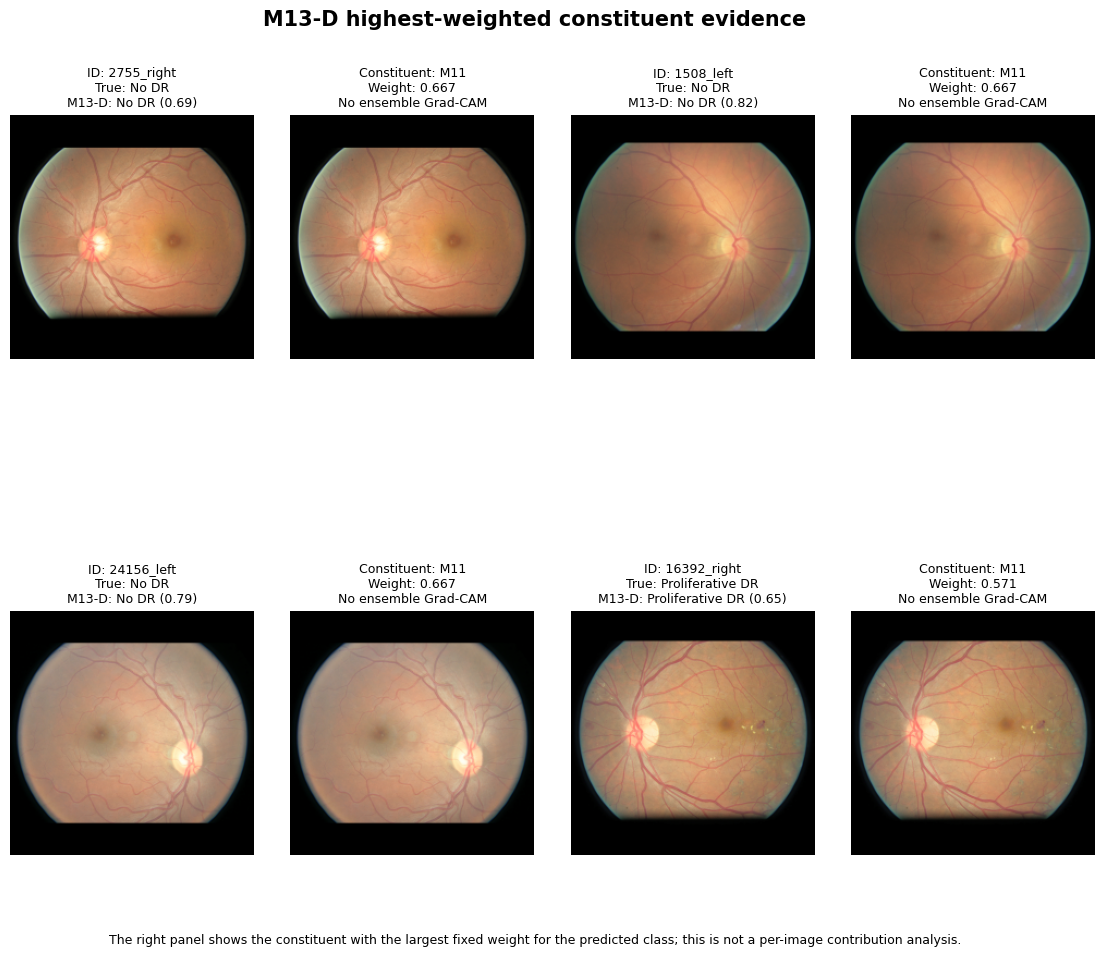

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/m13/m13_class_weight_constituent_evidence.png
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/m13/m13_class_weight_constituent_evidence.pdf


In [18]:
# ---------------------------------------------------------------------
# M13-D class-weight constituent table and compact 4-panel-per-row figure
# ---------------------------------------------------------------------

m13_manifest_rows = sample_manifest_df[
    sample_manifest_df["model"] == "M13-D"
].copy()

if len(m13_manifest_rows) == 0:
    m13_manifest_rows = m13_df.sample(
        n=min(N_PER_CATEGORY, len(m13_df)),
        random_state=SEED,
    ).copy()
    m13_manifest_rows["selection_category"] = "m13_general_sample"


# ---------------------------------------------------------------------
# Build highest-weighted class-specific constituent evidence table
# ---------------------------------------------------------------------

specialist_table_rows = []

for _, row in m13_manifest_rows.iterrows():
    image_id = str(row["image_id"])

    matching_m13_rows = m13_df[
        m13_df["image_id"].astype(str) == image_id
    ]

    if len(matching_m13_rows) == 0:
        print(
            f"M13-D prediction not found for {image_id}; skipping."
        )
        continue

    m13_row = matching_m13_rows.iloc[0]

    true_label = int(m13_row["true_label"])
    m13_prediction = int(m13_row["predicted_label"])
    m13_confidence = float(m13_row["confidence"])

    highest_weighted = highest_weighted_constituent_by_class[m13_prediction]
    specialist_name = str(highest_weighted["model"])
    specialist_weight = float(highest_weighted["weight"])

    specialist_predictions = a01_predictions.get(
        specialist_name
    )

    specialist_prediction = None
    specialist_confidence = float("nan")

    if specialist_predictions is not None:
        matching_specialist_rows = specialist_predictions[
            specialist_predictions["image_id"].astype(str) == image_id
        ]

        if len(matching_specialist_rows) > 0:
            specialist_prediction_row = matching_specialist_rows.iloc[0]

            specialist_prediction = int(
                specialist_prediction_row["predicted_label"]
            )

            probability_columns = [
                column
                for column in specialist_predictions.columns
                if column.startswith("prob_")
            ]

            if probability_columns:
                specialist_confidence = float(
                    specialist_prediction_row[
                        probability_columns
                    ].to_numpy(dtype=float).max()
                )

    specialist_table_rows.append({
        "image_id": image_id,
        "true_label": true_label,
        "m13_prediction": m13_prediction,
        "m13_confidence": m13_confidence,
        "highest_weighted_constituent": specialist_name,
        "specialist_weight": specialist_weight,
    })

m13_specialist_table_df = pd.DataFrame(
    specialist_table_rows
)

print(
    m13_specialist_table_df.to_string(index=False)
)

m13_table_path = (
    A02_LOG_DIR / "m13_class_weight_constituent_evidence.csv"
)
m13_specialist_table_df.to_csv(
    m13_table_path,
    index=False,
)

print(f"\nSaved -> {m13_table_path}")

print(
    "\nNote: this table identifies the constituent with the largest fixed "
    "weight for the predicted class. It is not a per-image contribution "
    "analysis or a complete decomposition of the ensemble decision."
)


# ---------------------------------------------------------------------
# Compact M13-D figure: 2 examples per row = 4 panels per row
# ---------------------------------------------------------------------

m13_output_dir = A02_FIGURE_DIR / "m13"
m13_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

m13_visual_rows = (
    m13_specialist_table_df
    .drop_duplicates("image_id")
    .head(min(4, len(m13_specialist_table_df)))
)

if len(m13_visual_rows) > 0:

    test_image_lookup = (
        test_df.assign(
            image_key=test_df["image"].astype(str)
        ).set_index("image_key")
    )

    n_examples = len(m13_visual_rows)
    examples_per_row = 2
    n_rows = int(np.ceil(n_examples / examples_per_row))
    n_cols = 4   # 2 examples × 2 panels each

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(14, 4.8 * n_rows),
        squeeze=False,
    )

    for ax_row in axes:
        for ax in ax_row:
            ax.axis("off")

    for idx, (_, row) in enumerate(
        m13_visual_rows.iterrows()
    ):
        grid_row = idx // examples_per_row
        example_pos = idx % examples_per_row

        left_ax = axes[grid_row, example_pos * 2]
        right_ax = axes[grid_row, example_pos * 2 + 1]

        image_id = str(row["image_id"])
        filepath = test_image_lookup.loc[
            image_id,
            "filepath",
        ]

        rgb_224 = preprocess_p0(
            filepath,
            224,
        )

        true_label = int(row["true_label"])
        m13_prediction = int(row["m13_prediction"])
        m13_confidence = float(row["m13_confidence"])
        specialist = str(row["highest_weighted_constituent"])
        specialist_weight = float(row["specialist_weight"])

        # Left panel: original image
        left_ax.imshow(rgb_224)
        left_ax.set_title(
            f"ID: {image_id}\n"
            f"True: {CLASS_NAMES[true_label]}\n"
            f"M13-D: {CLASS_NAMES[m13_prediction]} "
            f"({m13_confidence:.2f})",
            fontsize=9,
            pad=6,
        )
        left_ax.axis("off")

        # Right panel: highest-weighted constituent evidence
        if specialist == "DeiT-III":
            tensor = normalise_to_tensor(
                rgb_224,
                VIT_MEAN,
                VIT_STD,
            ).unsqueeze(0).to(device)

            attention_grid, _, _ = deit_attention_heatmap(
                tensor
            )

            attention_resized = cv2.resize(
                attention_grid,
                (224, 224),
                interpolation=cv2.INTER_CUBIC,
            )

            specialist_view = overlay_heatmap(
                rgb_224,
                attention_resized,
            )

            specialist_title = (
                "DeiT-III constituent\n"
                f"Weight: {specialist_weight:.3f}\n"
                "Attention rollout"
            )

        elif specialist == "M12":
            explanation = compute_m12_explanation(
                filepath
            )

            specialist_view = overlay_heatmap(
                explanation["global_image"],
                explanation["global_cam"],
            )

            specialist_title = (
                "M12 constituent\n"
                f"Weight: {specialist_weight:.3f}\n"
                "Global Grad-CAM"
            )

        else:
            specialist_view = rgb_224
            specialist_title = (
                f"Constituent: {specialist}\n"
                f"Weight: {specialist_weight:.3f}\n"
                "No ensemble Grad-CAM"
            )

        right_ax.imshow(specialist_view)
        right_ax.set_title(
            specialist_title,
            fontsize=9,
            pad=6,
        )
        right_ax.axis("off")

    fig.suptitle(
        "M13-D highest-weighted constituent evidence",
        fontsize=15,
        fontweight="bold",
        y=0.985,
    )

    fig.text(
        0.5,
        0.012,
        (
            "The right panel shows the constituent with the largest fixed "
            "weight for the predicted class; this is not a per-image "
            "contribution analysis."
        ),
        ha="center",
        fontsize=9,
    )

    plt.subplots_adjust(
        top=0.93,
        bottom=0.05,
        hspace=0.42,
        wspace=0.15,
    )

    m13_png_path = (
        m13_output_dir
        / "m13_class_weight_constituent_evidence.png"
    )

    m13_pdf_path = (
        m13_output_dir
        / "m13_class_weight_constituent_evidence.pdf"
    )

    plt.savefig(
        m13_png_path,
        dpi=400,
        bbox_inches="tight",
        pad_inches=0.12,
    )

    plt.savefig(
        m13_pdf_path,
        bbox_inches="tight",
        pad_inches=0.12,
    )

    plt.show()

    print(f"Saved -> {m13_png_path}")
    print(f"Saved -> {m13_pdf_path}")

else:
    print(
        "No M13-D examples were available; figure skipped."
    )

## 7. Failure-mode analysis

Quantitative tables across the four headline models.

In [19]:
failure_mode_rows = []
for model_name, df in a01_predictions.items():
    labels = df["true_label"].to_numpy()
    preds = df["predicted_label"].to_numpy()
    grade_error = preds - labels

    failure_mode_rows.append({
        "model": model_name,
        "under_grading_rate": float((grade_error < 0).mean()),
        "over_grading_rate": float((grade_error > 0).mean()),
        "one_grade_errors": int(np.sum(np.abs(grade_error) == 1)),
        "two_plus_grade_errors": int(np.sum(np.abs(grade_error) >= 2)),
        "mild_to_no_dr": int(np.sum((labels == 1) & (preds == 0))),
        "severe_to_moderate": int(np.sum((labels == 3) & (preds == 2))),
        "pdr_to_moderate": int(np.sum((labels == 4) & (preds == 2))),
    })
failure_mode_summary_df = pd.DataFrame(failure_mode_rows)
print(failure_mode_summary_df.to_string(index=False))
failure_mode_summary_df.to_csv(A02_LOG_DIR / "failure_mode_summary.csv", index=False)
print(f"\nSaved -> {A02_LOG_DIR / 'failure_mode_summary.csv'}")

          model  under_grading_rate  over_grading_rate  one_grade_errors  two_plus_grade_errors  mild_to_no_dr  severe_to_moderate  pdr_to_moderate
EfficientNet-B4            0.138710           0.293359              1638                    639            201                  35               20
       DeiT-III            0.141176           0.072676               562                    565            306                  56               26
            M12            0.116319           0.061480               644                    293            265                  39               18
          M13-D            0.127514           0.035863               523                    338            301                  48               20

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/analysis/A02_explainability_failure_analysis/failure_mode_summary.csv


In [20]:
high_confidence_error_rows = []
for model_name, df in a01_predictions.items():
    prob_cols = [c for c in df.columns if c.startswith("prob_")]
    confidences = df[prob_cols].max(axis=1) if prob_cols else df.get("confidence", pd.Series(np.nan, index=df.index))
    wrong_mask = df["predicted_label"] != df["true_label"]
    high_conf_wrong = df[wrong_mask & (confidences >= 0.80)].copy()
    high_conf_wrong["model"] = model_name
    high_conf_wrong["confidence"] = confidences[wrong_mask & (confidences >= 0.80)]
    high_confidence_error_rows.append(high_conf_wrong[["image_id", "true_label", "predicted_label", "confidence", "model"]])

high_confidence_errors_df = pd.concat(high_confidence_error_rows, ignore_index=True)
print(f"High-confidence errors (>=0.80) across all models: {len(high_confidence_errors_df)}")
high_confidence_errors_df.to_csv(A02_LOG_DIR / "high_confidence_errors.csv", index=False)
print(f"Saved -> {A02_LOG_DIR / 'high_confidence_errors.csv'}")

High-confidence errors (>=0.80) across all models: 483
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/analysis/A02_explainability_failure_analysis/high_confidence_errors.csv


In [21]:
persistent_wrong_ids = set(a01_predictions["M12"]["image_id"])
for model_name, df in a01_predictions.items():
    wrong_ids = set(df.loc[df["predicted_label"] != df["true_label"], "image_id"])
    persistent_wrong_ids &= wrong_ids

persistent_errors_df = a01_predictions["M12"][a01_predictions["M12"]["image_id"].isin(persistent_wrong_ids)][
    ["image_id", "true_label", "predicted_label"]
].copy()
print(f"Persistent errors (wrong in all {len(a01_predictions)} headline models): {len(persistent_errors_df)}")
persistent_errors_df.to_csv(A02_LOG_DIR / "persistent_errors.csv", index=False)
print(f"Saved -> {A02_LOG_DIR / 'persistent_errors.csv'}")

Persistent errors (wrong in all 4 headline models): 502
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/analysis/A02_explainability_failure_analysis/persistent_errors.csv


In [22]:
m12_m13_transitions = merged_m12_m13[merged_m12_m13["correct_m12"] != merged_m12_m13["correct_m13"]].copy()
m12_m13_transitions["transition_type"] = np.where(
    (~m12_m13_transitions["correct_m12"]) & (m12_m13_transitions["correct_m13"]), "corrected_by_m13",
    "introduced_by_m13",
)
m12_m13_transition_examples_df = m12_m13_transitions[
    ["image_id", "true_label", "predicted_label_m12", "predicted_label_m13", "transition_type"]
]
print(f"M12-M13 transitions: {len(m12_m13_transition_examples_df)} total "
      f"({(m12_m13_transition_examples_df['transition_type'] == 'corrected_by_m13').sum()} corrected, "
      f"{(m12_m13_transition_examples_df['transition_type'] == 'introduced_by_m13').sum()} introduced)")
m12_m13_transition_examples_df.to_csv(A02_LOG_DIR / "m12_m13_transition_examples.csv", index=False)
print(f"Saved -> {A02_LOG_DIR / 'm12_m13_transition_examples.csv'}")

M12-M13 transitions: 330 total (203 corrected, 127 introduced)
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/analysis/A02_explainability_failure_analysis/m12_m13_transition_examples.csv


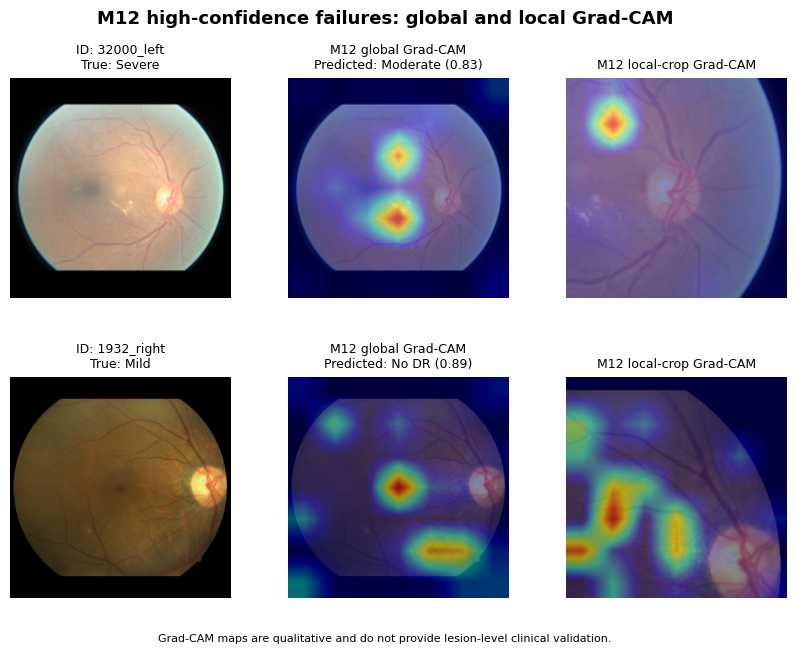

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/failure_grid_high_confidence_errors.png
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/failure_grid_high_confidence_errors.pdf


In [23]:
def make_failure_grid(
    image_ids: list,
    title: str,
    save_stem: str,
    max_images: int = 2,
):
    """
    Create a compact report-ready M12 failure grid.

    Each row contains:
    - original image
    - M12 global Grad-CAM
    - M12 local-crop Grad-CAM

    Saves a 400-dpi PNG and a vector PDF.
    """
    image_ids = list(image_ids)[:max_images]
    n_images = len(image_ids)

    if n_images == 0:
        print(
            f"No examples available for '{title}'; "
            "skipping grid."
        )
        return

    # Compact but wide enough for readable titles
    fig, axes = plt.subplots(
        n_images,
        3,
        figsize=(10.5, 3.25 * n_images),
        squeeze=False,
    )

    test_lookup = test_df.set_index("image")
    m12_lookup = m12_df.set_index("image_id")

    for row_index, image_id in enumerate(image_ids):
        filepath = test_lookup.loc[
            image_id,
            "filepath",
        ]

        m12_row = m12_lookup.loc[
            image_id
        ]

        true_label = int(
            m12_row["true_label"]
        )

        predicted_label = int(
            m12_row["predicted_label"]
        )

        confidence = float(
            m12_row["confidence"]
        )

        explanation = compute_m12_explanation(
            filepath
        )

        global_overlay = overlay_heatmap(
            explanation["global_image"],
            explanation["global_cam"],
        )

        local_overlay = overlay_heatmap(
            explanation["local_image"],
            explanation["local_cam"],
        )

        # ---------------------------------------------------------
        # Original image
        # ---------------------------------------------------------

        axes[row_index, 0].imshow(
            explanation["global_image"]
        )

        axes[row_index, 0].set_title(
            f"ID: {image_id}\n"
            f"True: {CLASS_NAMES[true_label]}",
            fontsize=9,
            pad=7,
        )

        # ---------------------------------------------------------
        # Global Grad-CAM
        # ---------------------------------------------------------

        axes[row_index, 1].imshow(
            global_overlay
        )

        axes[row_index, 1].set_title(
            "M12 global Grad-CAM\n"
            f"Predicted: "
            f"{CLASS_NAMES[predicted_label]} "
            f"({confidence:.2f})",
            fontsize=9,
            pad=7,
        )

        # ---------------------------------------------------------
        # Local-crop Grad-CAM
        # ---------------------------------------------------------

        axes[row_index, 2].imshow(
            local_overlay
        )

        axes[row_index, 2].set_title(
            "M12 local-crop Grad-CAM",
            fontsize=9,
            pad=7,
        )

        for column_index in range(3):
            axes[
                row_index,
                column_index,
            ].axis("off")

    fig.suptitle(
        title,
        fontsize=13,
        fontweight="bold",
        y=0.985,
    )

    fig.text(
        0.5,
        0.012,
        (
            "Grad-CAM maps are qualitative and do not provide "
            "lesion-level clinical validation."
        ),
        ha="center",
        fontsize=8,
    )

    # Extra space above the first-row titles prevents overlap
    plt.subplots_adjust(
        top=0.88,
        bottom=0.08,
        hspace=0.36,
        wspace=0.08,
    )

    png_path = (
        A02_FIGURE_DIR
        / f"{save_stem}.png"
    )

    pdf_path = (
        A02_FIGURE_DIR
        / f"{save_stem}.pdf"
    )

    plt.savefig(
        png_path,
        dpi=400,
        bbox_inches="tight",
        pad_inches=0.18,
    )

    plt.savefig(
        pdf_path,
        bbox_inches="tight",
        pad_inches=0.18,
    )

    plt.show()

    print(f"Saved -> {png_path}")
    print(f"Saved -> {pdf_path}")


failure_grid_ids = (
    sample_manifest_df[
        sample_manifest_df[
            "selection_category"
        ] == "high_confidence_incorrect"
    ]["image_id"]
    .drop_duplicates()
    .tolist()
)

make_failure_grid(
    image_ids=failure_grid_ids,
    title=(
        "M12 high-confidence failures: "
        "global and local Grad-CAM"
    ),
    save_stem=(
        "failure_grid_high_confidence_errors"
    ),
    max_images=2,
)

## 8. Artefact and shortcut analysis

The **sample list is fixed first** (the manifest from Section 2), then heuristic image-level
checks flag likely candidates for border/corner/blur/illumination issues automatically —
these heuristics are a starting point, not a substitute for the manual review the brief
explicitly allows (`review_notes` is left blank for manual completion).

In [24]:
def heuristic_artefact_checks(
    rgb_224: np.ndarray,
    cam: np.ndarray = None,
) -> dict:
    gray = cv2.cvtColor(rgb_224, cv2.COLOR_RGB2GRAY)

    border_width = 10
    border_mask = np.zeros_like(gray, dtype=bool)
    border_mask[:border_width, :] = True
    border_mask[-border_width:, :] = True
    border_mask[:, :border_width] = True
    border_mask[:, -border_width:] = True
    black_border_fraction = float((gray[border_mask] < 15).mean())

    corner_size = 25
    corners = [
        gray[:corner_size, :corner_size],
        gray[:corner_size, -corner_size:],
        gray[-corner_size:, :corner_size],
        gray[-corner_size:, -corner_size:],
    ]
    dark_corner_fraction = float(
        np.mean([(corner < 15).mean() for corner in corners])
    )

    blur_score = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    mean_brightness = float(gray.mean())
    brightness_std = float(gray.std())

    attention_on_border = np.nan
    attention_on_corner = np.nan
    if cam is not None:
        cam_resized = cv2.resize(
            cam,
            (rgb_224.shape[1], rgb_224.shape[0]),
        )
        overall_mean = float(cam_resized.mean()) + 1e-8
        attention_on_border = float(
            cam_resized[border_mask].mean() / overall_mean
        )
        corner_cam = np.concatenate([
            cam_resized[:corner_size, :corner_size].ravel(),
            cam_resized[:corner_size, -corner_size:].ravel(),
            cam_resized[-corner_size:, :corner_size].ravel(),
            cam_resized[-corner_size:, -corner_size:].ravel(),
        ])
        attention_on_corner = float(
            corner_cam.mean() / overall_mean
        )

    return {
        "attention_on_border": attention_on_border,
        "attention_on_corner": attention_on_corner,
        "attention_on_optic_disc": np.nan,
        "blur_present": bool(blur_score < 100),
        "illumination_issue": bool(
            mean_brightness < 40
            or mean_brightness > 220
            or brightness_std < 15
        ),
        "crop_issue": bool(
            black_border_fraction > 0.3
            or dark_corner_fraction > 0.5
        ),
    }


artefact_rows = []
seen_image_ids = set()
m12_lookup = m12_df.set_index("image_id")

for _, row in sample_manifest_df.iterrows():
    image_id = row["image_id"]
    if image_id in seen_image_ids or image_id not in m12_lookup.index:
        continue
    seen_image_ids.add(image_id)

    filepath = test_df.set_index("image").loc[image_id, "filepath"]
    explanation = compute_m12_explanation(filepath)
    checks = heuristic_artefact_checks(
        explanation["global_image"],
        explanation["global_cam"],
    )
    prediction_row = m12_lookup.loc[image_id]

    artefact_rows.append({
        "image_id": image_id,
        "model": "M12",
        "prediction_correct": bool(
            int(explanation["prediction"])
            == int(prediction_row["true_label"])
        ),
        "attention_on_border": checks["attention_on_border"],
        "attention_on_corner": checks["attention_on_corner"],
        "attention_on_optic_disc": checks["attention_on_optic_disc"],
        "blur_present": checks["blur_present"],
        "illumination_issue": checks["illumination_issue"],
        "crop_issue": checks["crop_issue"],
        "review_notes": "",
    })

artefact_review_df = pd.DataFrame(artefact_rows)
print(artefact_review_df.to_string(index=False))
artefact_path = A02_LOG_DIR / "artefact_review_table.csv"
artefact_review_df.to_csv(artefact_path, index=False)
print(f"\nSaved -> {artefact_path}")
print(
    "\nBorder/corner scores use the actual M12 global Grad-CAM. "
    "Values above 1 indicate above-average attention in that region. "
    "Optic-disc attention and notes require manual review."
)


   image_id model  prediction_correct  attention_on_border  attention_on_corner  attention_on_optic_disc  blur_present  illumination_issue  crop_issue review_notes
38248_right   M12                True             0.469475             0.903899                      NaN         False               False        True             
34138_right   M12                True             0.872920             1.766758                      NaN         False               False        True             
  1595_left   M12                True             0.682544             1.388606                      NaN         False                True        True             
 24762_left   M12                True             0.911645             2.924699                      NaN          True               False        True             
   880_left   M12                True             0.818955             2.023356                      NaN          True                True        True             
32564_right   M1

## 9. Bias and subgroup evaluation

**Only subgroup variables genuinely available in this dataset** are used: left/right eye
(from the split CSV), class severity, and image-quality metrics computed directly from each
image (brightness, contrast, blur/sharpness, crop quality, fundus coverage) — all
deterministic, computable properties of the image itself. **No demographic variable (sex,
age, ethnicity) is invented**, since none exists in this project's manifest.

In [25]:
def compute_image_quality_metrics(rgb_224: np.ndarray) -> dict:
    gray = cv2.cvtColor(rgb_224, cv2.COLOR_RGB2GRAY)
    brightness = float(gray.mean())
    contrast = float(gray.std())
    sharpness = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    fundus_mask = gray > 15
    fundus_coverage = float(fundus_mask.mean())
    return {"brightness": brightness, "contrast": contrast, "sharpness": sharpness, "fundus_coverage": fundus_coverage}


print("Computing image-quality metrics for the full test set (used to define quality subgroups)...")
quality_rows = []
for _, row in test_df.iterrows():
    rgb_224 = preprocess_p0(row["filepath"], 224)
    metrics = compute_image_quality_metrics(rgb_224)
    metrics["image_id"] = row["image"]
    quality_rows.append(metrics)
quality_df = pd.DataFrame(quality_rows)

brightness_median = quality_df["brightness"].median()
sharpness_median = quality_df["sharpness"].median()
quality_df["brightness_group"] = np.where(quality_df["brightness"] >= brightness_median, "brighter_half", "darker_half")
quality_df["sharpness_group"] = np.where(quality_df["sharpness"] >= sharpness_median, "sharper_half", "blurrier_half")
print(f"Image-quality metrics computed for {len(quality_df):,} test images.")

Computing image-quality metrics for the full test set (used to define quality subgroups)...
Image-quality metrics computed for 5,270 test images.


In [26]:
def expected_calibration_error(
    labels,
    probabilities,
    n_bins=15,
):
    if probabilities is None or len(probabilities) == 0:
        return np.nan

    confidences = probabilities.max(axis=1)
    predictions = probabilities.argmax(axis=1)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = (confidences > lower) & (confidences <= upper)
        if not np.any(in_bin):
            continue
        bin_accuracy = np.mean(predictions[in_bin] == labels[in_bin])
        bin_confidence = np.mean(confidences[in_bin])
        ece += np.mean(in_bin) * abs(bin_accuracy - bin_confidence)

    return float(ece)


def bootstrap_qwk_ci(
    labels,
    preds,
    n_bootstrap=1000,
    seed=SEED,
):
    rng_local = np.random.default_rng(seed)
    n = len(labels)
    samples = np.empty(n_bootstrap)

    for bootstrap_index in range(n_bootstrap):
        indices = rng_local.integers(0, n, n)
        if len(set(labels[indices])) > 1:
            samples[bootstrap_index] = cohen_kappa_score(
                labels[indices],
                preds[indices],
                weights="quadratic",
            )
        else:
            samples[bootstrap_index] = np.nan

    valid = samples[~np.isnan(samples)]
    if len(valid) == 0:
        return np.nan, np.nan

    return (
        float(np.percentile(valid, 2.5)),
        float(np.percentile(valid, 97.5)),
    )


def subgroup_metrics(
    labels,
    preds,
    confidences,
    probabilities=None,
    n_min_stable=30,
):
    n = len(labels)
    stable = n >= n_min_stable and len(set(labels)) > 1

    metrics = {
        "n": n,
        "qwk": (
            cohen_kappa_score(
                labels,
                preds,
                weights="quadratic",
            )
            if stable
            else np.nan
        ),
        "macro_f1": f1_score(
            labels,
            preds,
            average="macro",
            zero_division=0,
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(labels, preds)
            if len(np.unique(labels)) > 1
            else np.nan
        ),
        "accuracy": accuracy_score(labels, preds),
        "mean_confidence": float(np.mean(confidences)),
        "ece": expected_calibration_error(
            labels,
            probabilities,
            n_bins=15,
        ),
        "under_grading_rate": float(np.mean(preds < labels)),
        "over_grading_rate": float(np.mean(preds > labels)),
        "qwk_stable": stable,
    }

    if stable:
        (
            metrics["qwk_ci_lower"],
            metrics["qwk_ci_upper"],
        ) = bootstrap_qwk_ci(labels, preds)
    else:
        metrics["qwk_ci_lower"] = np.nan
        metrics["qwk_ci_upper"] = np.nan

    return metrics


subgroup_definitions = []
merged_quality = test_df.rename(
    columns={"image": "image_id"}
).merge(
    quality_df,
    on="image_id",
)

for model_name, model_df in a01_predictions.items():
    model_df = model_df.copy()
    probability_columns = [
        column
        for column in model_df.columns
        if column.startswith("prob_")
    ]

    if len(probability_columns) == NUM_CLASSES:
        model_df["confidence"] = model_df[
            probability_columns
        ].max(axis=1)
    elif "confidence" not in model_df.columns:
        model_df["confidence"] = np.nan

    model_df = model_df.merge(
        merged_quality[
            [
                "image_id",
                "eye",
                "brightness_group",
                "sharpness_group",
            ]
        ],
        on="image_id",
    )

    subgroup_pairs = [
        ("eye", "eye"),
        ("brightness_group", "brightness"),
        ("sharpness_group", "sharpness"),
    ]

    for subgroup_column, subgroup_label in subgroup_pairs:
        subgroup_values = sorted(
            model_df[subgroup_column].dropna().unique()
        )
        for subgroup_value in subgroup_values:
            subgroup = model_df[
                model_df[subgroup_column] == subgroup_value
            ]
            subgroup_probabilities = (
                subgroup[probability_columns].to_numpy()
                if len(probability_columns) == NUM_CLASSES
                else None
            )
            metrics = subgroup_metrics(
                subgroup["true_label"].to_numpy(),
                subgroup["predicted_label"].to_numpy(),
                subgroup["confidence"].to_numpy(),
                probabilities=subgroup_probabilities,
            )
            metrics.update({
                "model": model_name,
                "subgroup_type": subgroup_label,
                "subgroup_value": subgroup_value,
            })
            subgroup_definitions.append(metrics)

    for class_id in range(NUM_CLASSES):
        subgroup = model_df[
            model_df["true_label"] == class_id
        ]
        subgroup_probabilities = (
            subgroup[probability_columns].to_numpy()
            if len(probability_columns) == NUM_CLASSES
            else None
        )
        metrics = subgroup_metrics(
            subgroup["true_label"].to_numpy(),
            subgroup["predicted_label"].to_numpy(),
            subgroup["confidence"].to_numpy(),
            probabilities=subgroup_probabilities,
        )
        metrics.update({
            "model": model_name,
            "subgroup_type": "true_class",
            "subgroup_value": CLASS_NAMES[class_id],
        })
        subgroup_definitions.append(metrics)

subgroup_performance_a02_df = pd.DataFrame(
    subgroup_definitions
)
print(
    subgroup_performance_a02_df
    .round(4)
    .to_string(index=False)
)
subgroup_path = A02_LOG_DIR / "subgroup_performance.csv"
subgroup_performance_a02_df.to_csv(
    subgroup_path,
    index=False,
)
print(f"\nSaved -> {subgroup_path}")

n_exploratory = int(
    (subgroup_performance_a02_df["n"] < 30).sum()
)
if n_exploratory > 0:
    print(
        f"\nWARNING: {n_exploratory} subgroup row(s) "
        "have fewer than 30 images. Results for these "
        "subgroups are exploratory."
    )


   n    qwk  macro_f1  balanced_accuracy  accuracy  mean_confidence    ece  under_grading_rate  over_grading_rate  qwk_stable  qwk_ci_lower  qwk_ci_upper           model subgroup_type   subgroup_value
2635 0.4997    0.3927             0.4455    0.5609           0.4390 0.1241              0.1416             0.2975        True        0.4568        0.5409 EfficientNet-B4           eye             left
2635 0.5336    0.4001             0.4430    0.5750           0.4424 0.1361              0.1359             0.2892        True        0.4904        0.5707 EfficientNet-B4           eye            right
2635 0.5188    0.3957             0.4295    0.5844           0.4412 0.1476              0.1507             0.2649        True        0.4727        0.5573 EfficientNet-B4    brightness    brighter_half
2635 0.5137    0.3951             0.4564    0.5514           0.4403 0.1142              0.1268             0.3218        True        0.4702        0.5521 EfficientNet-B4    brightness      darker_

## 10. Report-ready figures

All at 300 dpi, with clear titles, true/predicted labels, confidence, and model name.

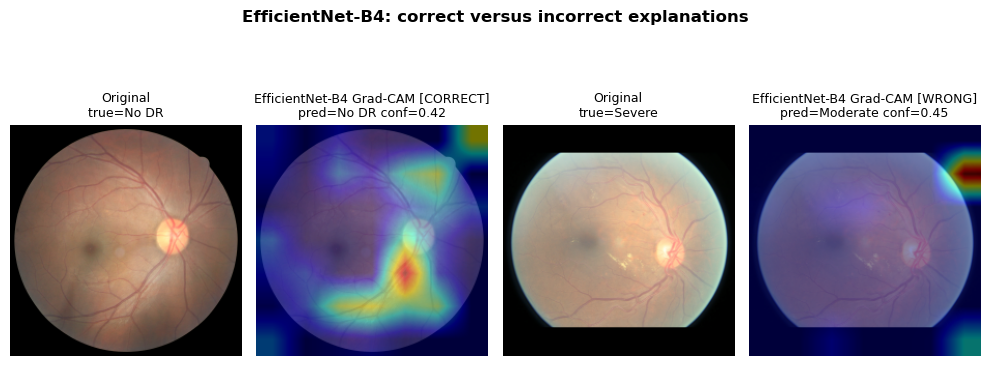

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/A02_figure_01_correct_vs_incorrect_explanations.png


In [27]:
# Figure 1: EfficientNet-B4 correct versus incorrect explanations
correct_id = sample_manifest_df[
    sample_manifest_df["selection_category"] == "correct_high_confidence"
]["image_id"].head(1).tolist()
incorrect_id = sample_manifest_df[
    sample_manifest_df["selection_category"] == "high_confidence_incorrect"
]["image_id"].head(1).tolist()
example_ids = correct_id + incorrect_id

if example_ids:
    fig, axes = plt.subplots(
        1,
        len(example_ids) * 2,
        figsize=(5 * len(example_ids), 4.5),
    )
    if len(example_ids) * 2 == 1:
        axes = [axes]

    eff_lookup = a01_predictions["EfficientNet-B4"].set_index("image_id")
    col = 0

    for image_id in example_ids:
        filepath = test_df.set_index("image").loc[image_id, "filepath"]
        rgb_224 = preprocess_p0(filepath, 224)
        eff_row = eff_lookup.loc[image_id]
        true_label = int(eff_row["true_label"])

        tensor = normalise_to_tensor(
            rgb_224, VIT_MEAN, VIT_STD
        ).unsqueeze(0).to(device)

        with torch.no_grad():
            eff_logits = efficientnet_backbone(tensor)
            eff_probs = F.softmax(eff_logits, dim=1)[0]
            eff_pred = int(eff_probs.argmax())
            eff_conf = float(eff_probs.max())

        cam = efficientnet_gradcam(tensor, eff_pred)
        overlay = overlay_heatmap(rgb_224, cam)
        correctness = "CORRECT" if eff_pred == true_label else "WRONG"

        axes[col].imshow(rgb_224)
        axes[col].set_title(
            f"Original\ntrue={CLASS_NAMES[true_label]}",
            fontsize=9,
        )
        axes[col].axis("off")

        axes[col + 1].imshow(overlay)
        axes[col + 1].set_title(
            f"EfficientNet-B4 Grad-CAM [{correctness}]\n"
            f"pred={CLASS_NAMES[eff_pred]} conf={eff_conf:.2f}",
            fontsize=9,
        )
        axes[col + 1].axis("off")
        col += 2

    fig.suptitle(
        "EfficientNet-B4: correct versus incorrect explanations",
        fontsize=12,
        fontweight="bold",
    )
    plt.tight_layout()
    save_path = (
        A02_FIGURE_DIR
        / "A02_figure_01_correct_vs_incorrect_explanations.png"
    )
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {save_path}")
else:
    print("No suitable examples were available for Figure 1.")


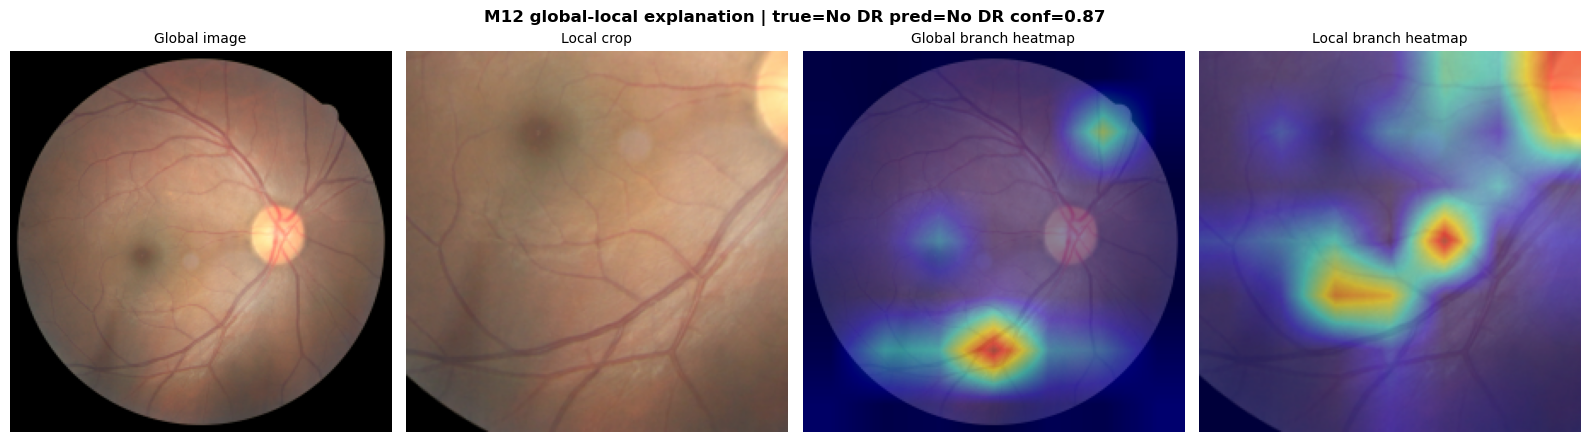

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/A02_figure_02_m12_global_local_explanations.png


In [28]:
# Figure 2: M12 global/local explanations (reuse one manifest example)
if len(m12_manifest_rows) > 0:
    example_row = m12_manifest_rows.iloc[0]
    image_id = example_row["image_id"]
    filepath = test_df.set_index("image").loc[image_id, "filepath"]
    image_full = preprocess_p0_full(filepath)
    global_224 = cv2.resize(image_full, (M12_IMAGE_SIZE, M12_IMAGE_SIZE), interpolation=cv2.INTER_AREA)
    pseudo_mask, local_224 = m12_detect_and_crop_and_mask(image_full)

    global_t = normalise_to_tensor(global_224, M12_MEAN, M12_STD).unsqueeze(0).to(device)
    local_t = normalise_to_tensor(local_224, M12_MEAN, M12_STD).unsqueeze(0).to(device)
    guided_224 = m12_make_guided_view(global_224, pseudo_mask)
    guided_t = normalise_to_tensor(guided_224, M12_MEAN, M12_STD).unsqueeze(0).to(device)

    m12_model.zero_grad(set_to_none=True)
    logits = m12_model(global_t, local_t, guided_t)
    probs = F.softmax(logits, dim=1)[0]
    pred, conf = int(probs.argmax().item()), float(probs.detach().max().item())
    logits[0, pred].backward()
    activations, gradients = m12_activations["value"], m12_gradients["value"]
    cams = []
    for view_idx in range(2):
        weights = gradients[view_idx:view_idx + 1].mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * activations[view_idx:view_idx + 1]).sum(dim=1, keepdim=True)).squeeze().cpu().numpy()
        cams.append(cam / cam.max() if cam.max() > 0 else cam)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
    axes[0].imshow(global_224); axes[0].set_title("Global image", fontsize=10)
    axes[1].imshow(local_224); axes[1].set_title("Local crop", fontsize=10)
    axes[2].imshow(overlay_heatmap(global_224, cams[0])); axes[2].set_title("Global branch heatmap", fontsize=10)
    axes[3].imshow(overlay_heatmap(local_224, cams[1])); axes[3].set_title("Local branch heatmap", fontsize=10)
    for ax in axes:
        ax.axis("off")
    fig.suptitle(
        f"M12 global-local explanation | true={CLASS_NAMES[int(example_row['true_label'])]} "
        f"pred={CLASS_NAMES[pred]} conf={conf:.2f}", fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(A02_FIGURE_DIR / "A02_figure_02_m12_global_local_explanations.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {A02_FIGURE_DIR / 'A02_figure_02_m12_global_local_explanations.png'}")

### Figure 3 is generated earlier

The compact two-case M12 high-confidence failure figure generated in Section 7 is retained
as Figure 3. A second, larger version is intentionally not generated here because it would
duplicate the same cases and explanations.


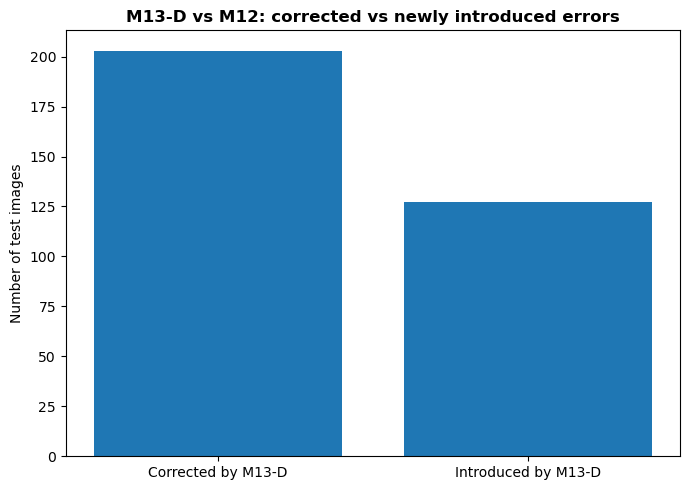

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/A02_figure_04_m13_corrected_vs_introduced_errors.png


In [29]:
# Figure 4: M13 corrected vs introduced errors (bar chart)
fig, ax = plt.subplots(figsize=(7, 5))
counts = [
    (m12_m13_transition_examples_df["transition_type"] == "corrected_by_m13").sum(),
    (m12_m13_transition_examples_df["transition_type"] == "introduced_by_m13").sum(),
]
ax.bar(["Corrected by M13-D", "Introduced by M13-D"], counts)
ax.set_ylabel("Number of test images")
ax.set_title("M13-D vs M12: corrected vs newly introduced errors", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(A02_FIGURE_DIR / "A02_figure_04_m13_corrected_vs_introduced_errors.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved -> {A02_FIGURE_DIR / 'A02_figure_04_m13_corrected_vs_introduced_errors.png'}")

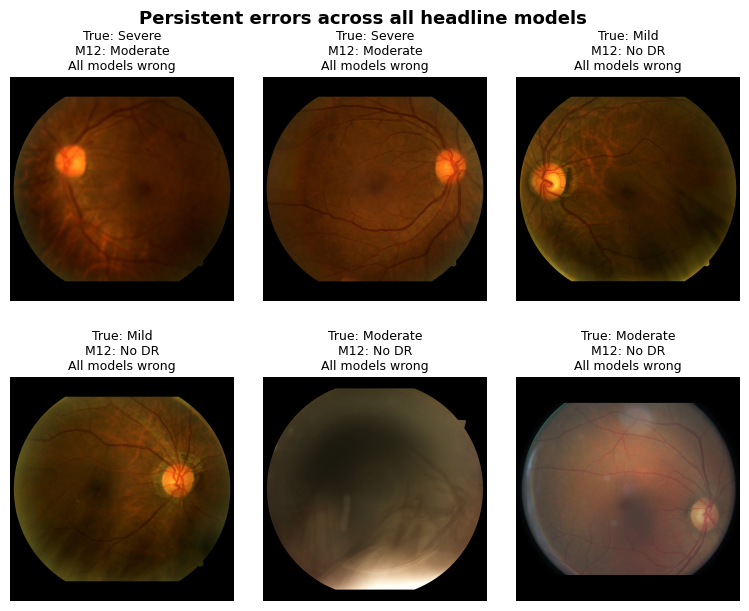

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/A02_figure_05_persistent_errors_across_models.png
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/A02_figure_05_persistent_errors_across_models.pdf


In [30]:
# Figure 5: compact persistent-error grid

persistent_ids = (
    persistent_errors_df["image_id"]
    .drop_duplicates()
    .tolist()[:6]
)

if len(persistent_ids) > 0:
    n_cols = 3
    n_rows = int(np.ceil(len(persistent_ids) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(9.5, 3.4 * n_rows),
        squeeze=False,
    )

    axes = axes.flatten()
    test_lookup = test_df.set_index("image")

    for ax, image_id in zip(axes, persistent_ids):
        filepath = test_lookup.loc[
            image_id,
            "filepath",
        ]

        rgb_224 = preprocess_p0(
            filepath,
            224,
        )

        row = (
            persistent_errors_df[
                persistent_errors_df["image_id"]
                == image_id
            ]
            .iloc[0]
        )

        true_label = int(
            row["true_label"]
        )

        predicted_label = int(
            row["predicted_label"]
        )

        ax.imshow(rgb_224)

        ax.set_title(
            f"True: {CLASS_NAMES[true_label]}\n"
            f"M12: {CLASS_NAMES[predicted_label]}\n"
            "All models wrong",
            fontsize=9,
            pad=6,
        )

        ax.axis("off")

    # Hide unused panels
    for ax in axes[len(persistent_ids):]:
        ax.axis("off")

    fig.suptitle(
        "Persistent errors across all headline models",
        fontsize=13,
        fontweight="bold",
        y=0.98,
    )

    plt.subplots_adjust(
        top=0.88,
        hspace=0.34,
        wspace=0.10,
    )

    png_path = (
        A02_FIGURE_DIR
        / "A02_figure_05_persistent_errors_across_models.png"
    )

    pdf_path = (
        A02_FIGURE_DIR
        / "A02_figure_05_persistent_errors_across_models.pdf"
    )

    plt.savefig(
        png_path,
        dpi=400,
        bbox_inches="tight",
        pad_inches=0.15,
    )

    plt.savefig(
        pdf_path,
        bbox_inches="tight",
        pad_inches=0.15,
    )

    plt.show()

    print(f"Saved -> {png_path}")
    print(f"Saved -> {pdf_path}")

else:
    print(
        "No persistent errors found across all "
        "headline models; Figure 5 skipped."
    )

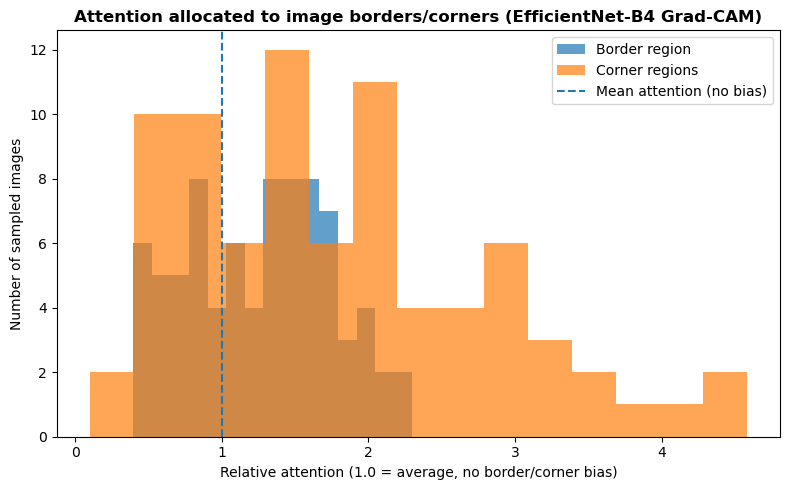

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/A02_figure_06_attention_to_image_artefacts.png


In [31]:
# Figure 6: attention to image artefacts (border/corner attention distribution)
efficientnet_border_scores = []
for _, row in sample_manifest_df.iterrows():
    image_id = row["image_id"]
    filepath = test_df.set_index("image").loc[image_id, "filepath"]
    rgb_224 = preprocess_p0(filepath, 224)
    tensor = normalise_to_tensor(rgb_224, VIT_MEAN, VIT_STD).unsqueeze(0).to(device)
    with torch.no_grad():
        eff_pred = int(F.softmax(efficientnet_backbone(tensor), dim=1).argmax())
    cam = efficientnet_gradcam(tensor, eff_pred)
    checks = heuristic_artefact_checks(rgb_224, cam)
    efficientnet_border_scores.append({"image_id": image_id, "attention_on_border": checks["attention_on_border"], "attention_on_corner": checks["attention_on_corner"]})

border_scores_df = pd.DataFrame(efficientnet_border_scores)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(border_scores_df["attention_on_border"].dropna(), bins=15, alpha=0.7, label="Border region")
ax.hist(border_scores_df["attention_on_corner"].dropna(), bins=15, alpha=0.7, label="Corner regions")
ax.axvline(1.0, linestyle="--", label="Mean attention (no bias)")
ax.set_xlabel("Relative attention (1.0 = average, no border/corner bias)")
ax.set_ylabel("Number of sampled images")
ax.set_title("Attention allocated to image borders/corners (EfficientNet-B4 Grad-CAM)", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(A02_FIGURE_DIR / "A02_figure_06_attention_to_image_artefacts.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved -> {A02_FIGURE_DIR / 'A02_figure_06_attention_to_image_artefacts.png'}")

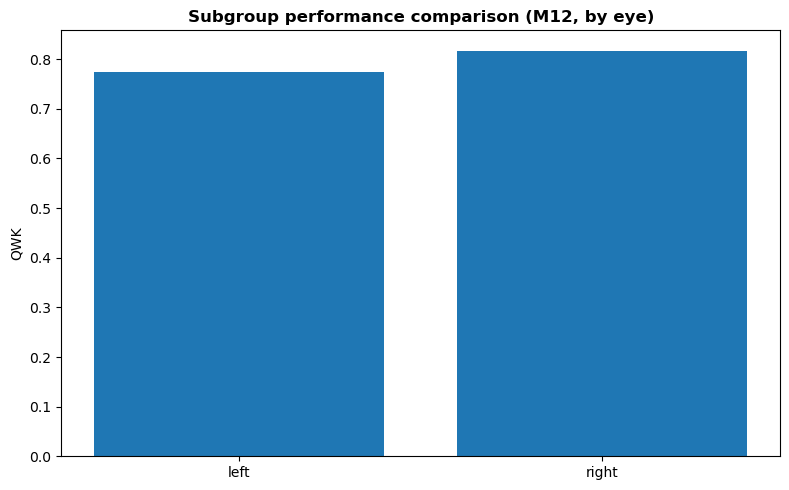

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/A02_figure_07_subgroup_performance_comparison.png


In [32]:
# Figure 7: subgroup performance comparison
plot_df = subgroup_performance_a02_df[
    (subgroup_performance_a02_df["subgroup_type"] == "eye") & (subgroup_performance_a02_df["model"] == "M12")
]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(plot_df["subgroup_value"], plot_df["qwk"])
ax.set_ylabel("QWK")
ax.set_title("Subgroup performance comparison (M12, by eye)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(A02_FIGURE_DIR / "A02_figure_07_subgroup_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved -> {A02_FIGURE_DIR / 'A02_figure_07_subgroup_performance_comparison.png'}")

## 10A. Report-ready cross-model explainability comparison

The same predetermined frozen test images are compared across:

- **EfficientNet-B4 Exp01:** Grad-CAM
- **DeiT-III D07:** transformer attention rollout
- **MaxViT-Tiny M12:** global-branch and local-branch Grad-CAM
- **M13-D:** frozen class probabilities plus the constituent with the largest fixed
  class-specific weight for the predicted class

M13-D has no single valid ensemble Grad-CAM. The highest-weighted constituent is reported
only as configuration-level context; it is not a per-image contribution analysis. No
artificial ensemble heatmap is created.

Report-ready figures are saved as 400-dpi PNG and vector PDF files.


In [33]:
# Deterministic report sample:
# 1) one correct high-confidence M12 case,
# 2) one genuine Mild -> No DR M12 error,
# 3) one error shared by all headline systems.

report_case_specs = [
    ("correct_high_confidence", "Correct high-confidence"),
    ("mild_predicted_as_no_dr", "Mild predicted as No DR"),
    ("all_headline_models_wrong", "Persistent error"),
]

report_case_rows = []
used_ids = set()

for category, display_name in report_case_specs:
    candidates = sample_manifest_df[
        sample_manifest_df["selection_category"] == category
    ].copy()

    # Use the full persistent-error table only when the manifest category
    # is unavailable.
    if len(candidates) == 0 and category == "all_headline_models_wrong":
        candidates = persistent_errors_df.copy()

    for _, candidate in candidates.iterrows():
        image_id = str(candidate["image_id"])

        if image_id in used_ids:
            continue

        m12_case = (
            a01_predictions["M12"]
            .set_index("image_id")
            .loc[image_id]
        )

        true_label = int(m12_case["true_label"])
        predicted_label = int(m12_case["predicted_label"])

        # Verify that the displayed label accurately describes the case.
        if category == "correct_high_confidence":
            if predicted_label != true_label:
                continue
            actual_name = "Correct high-confidence"

        elif category == "mild_predicted_as_no_dr":
            if not (true_label == 1 and predicted_label == 0):
                continue
            actual_name = "Mild predicted as No DR"

        else:
            actual_name = "Persistent error"

        used_ids.add(image_id)
        report_case_rows.append({
            "image_id": image_id,
            "case_name": actual_name,
            "selection_category": category,
        })
        break

# Deterministic fallback without assigning an inaccurate clinical/error label.
if len(report_case_rows) < 3:
    fallback = (
        sample_manifest_df
        .drop_duplicates("image_id")
        .sort_values(
            ["selection_category", "selection_rank"],
            kind="stable",
        )
    )

    for _, candidate in fallback.iterrows():
        image_id = str(candidate["image_id"])

        if image_id in used_ids:
            continue

        m12_case = (
            a01_predictions["M12"]
            .set_index("image_id")
            .loc[image_id]
        )
        true_label = int(m12_case["true_label"])
        predicted_label = int(m12_case["predicted_label"])

        if true_label == predicted_label:
            actual_name = "Additional correct case"
        elif abs(predicted_label - true_label) >= 2:
            actual_name = "Two-or-more-grade error"
        else:
            actual_name = (
                f"{CLASS_NAMES[true_label]} predicted as "
                f"{CLASS_NAMES[predicted_label]}"
            )

        used_ids.add(image_id)
        report_case_rows.append({
            "image_id": image_id,
            "case_name": actual_name,
            "selection_category": str(candidate["selection_category"]),
        })

        if len(report_case_rows) == 3:
            break

report_case_df = pd.DataFrame(report_case_rows[:3])

if len(report_case_df) == 0:
    raise RuntimeError(
        "No deterministic report-ready explanation cases were available."
    )

report_case_path = (
    A02_LOG_DIR / "report_ready_explanation_cases.csv"
)
report_case_df.to_csv(
    report_case_path,
    index=False,
)

print(report_case_df.to_string(index=False))
print(f"\nSaved -> {report_case_path}")


   image_id               case_name        selection_category
38248_right Correct high-confidence   correct_high_confidence
29654_right Mild predicted as No DR   mild_predicted_as_no_dr
 24772_left        Persistent error all_headline_models_wrong

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/analysis/A02_explainability_failure_analysis/report_ready_explanation_cases.csv


In [34]:

def save_report_figure(fig, stem):
    """Save a clear raster copy and a vector PDF copy."""
    png_path = A02_FIGURE_DIR / f"{stem}.png"
    pdf_path = A02_FIGURE_DIR / f"{stem}.pdf"

    fig.savefig(
        png_path,
        dpi=400,
        bbox_inches="tight",
        pad_inches=0.25,
    )
    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        pad_inches=0.25,
    )

    print(f"Saved -> {png_path}")
    print(f"Saved -> {pdf_path}")
    return png_path, pdf_path


def short_prediction_title(model_name, true_label, pred_label, confidence):
    correctness = "Correct" if pred_label == true_label else "Wrong"
    return (
        f"{model_name}\n"
        f"Pred: {CLASS_NAMES[pred_label]} ({confidence:.2f})\n"
        f"{correctness}"
    )


def get_frozen_prediction(model_name, image_id):
    table = a01_predictions[model_name].set_index("image_id")
    row = table.loc[image_id]
    probability_columns = [
        column
        for column in table.columns
        if column.startswith("prob_")
    ]

    if len(probability_columns) == NUM_CLASSES:
        probabilities = row[probability_columns].to_numpy(dtype=float)
        confidence = float(probabilities.max().item())
    else:
        probabilities = None
        confidence = float(row.get("confidence", np.nan))

    return {
        "true_label": int(row["true_label"]),
        "predicted_label": int(row["predicted_label"]),
        "confidence": confidence,
        "probabilities": probabilities,
    }


def get_efficientnet_explanation(image_path):
    rgb_224 = preprocess_p0(image_path, 224)
    tensor = normalise_to_tensor(
        rgb_224,
        VIT_MEAN,
        VIT_STD,
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = efficientnet_backbone(tensor)
        probabilities = F.softmax(logits, dim=1)[0]
        predicted_label = int(probabilities.argmax().item())
        confidence = float(probabilities.max().item())

    cam = efficientnet_gradcam(tensor, predicted_label)
    return {
        "image": rgb_224,
        "overlay": overlay_heatmap(rgb_224, cam),
        "predicted_label": predicted_label,
        "confidence": confidence,
    }


def get_deit_explanation(image_path):
    rgb_224 = preprocess_p0(image_path, 224)
    tensor = normalise_to_tensor(
        rgb_224,
        VIT_MEAN,
        VIT_STD,
    ).unsqueeze(0).to(device)

    attention_grid, predicted_label, confidence = (
        deit_attention_heatmap(tensor)
    )
    attention_resized = cv2.resize(
        attention_grid,
        (224, 224),
        interpolation=cv2.INTER_CUBIC,
    )

    return {
        "image": rgb_224,
        "overlay": overlay_heatmap(
            rgb_224,
            attention_resized,
        ),
        "attention": attention_resized,
        "predicted_label": predicted_label,
        "confidence": confidence,
    }


def get_m13_evidence(image_id):
    m13_row = m13_df.set_index("image_id").loc[image_id]
    true_label = int(m13_row["true_label"])
    predicted_label = int(m13_row["predicted_label"])

    probability_columns = [
        column
        for column in m13_df.columns
        if column.startswith("prob_")
    ]
    probabilities = m13_row[probability_columns].to_numpy(dtype=float)
    confidence = float(probabilities.max().item())

    highest_weighted = highest_weighted_constituent_by_class[predicted_label]

    return {
        "true_label": true_label,
        "predicted_label": predicted_label,
        "confidence": confidence,
        "probabilities": probabilities,
        "highest_weighted_constituent": highest_weighted["model"],
        "constituent_weight": float(highest_weighted["weight"]),
    }


def draw_m13_probability_panel(ax, evidence):
    bars = ax.barh(
        np.arange(NUM_CLASSES),
        evidence["probabilities"],
    )
    ax.set_yticks(
        np.arange(NUM_CLASSES),
        CLASS_NAMES,
        fontsize=8,
    )
    ax.set_xlim(0, 1)
    ax.invert_yaxis()
    ax.set_xlabel("Probability", fontsize=8)
    ax.tick_params(axis="x", labelsize=8)
    ax.set_title(
        "M13-D ensemble\n"
        f"Pred: {CLASS_NAMES[evidence['predicted_label']]} "
        f"({evidence['confidence']:.2f})\n"
        f"Highest fixed weight: {evidence['highest_weighted_constituent']} "
        f"(w={evidence['constituent_weight']:.3f})",
        fontsize=9,
    )

    for bar, value in zip(bars, evidence["probabilities"]):
        ax.text(
            min(float(value) + 0.02, 0.96),
            bar.get_y() + bar.get_height() / 2,
            f"{float(value):.2f}",
            va="center",
            fontsize=7,
        )


Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/A02_figure_08_best_models_shared_image_comparison.png
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/A02_figure_08_best_models_shared_image_comparison.pdf


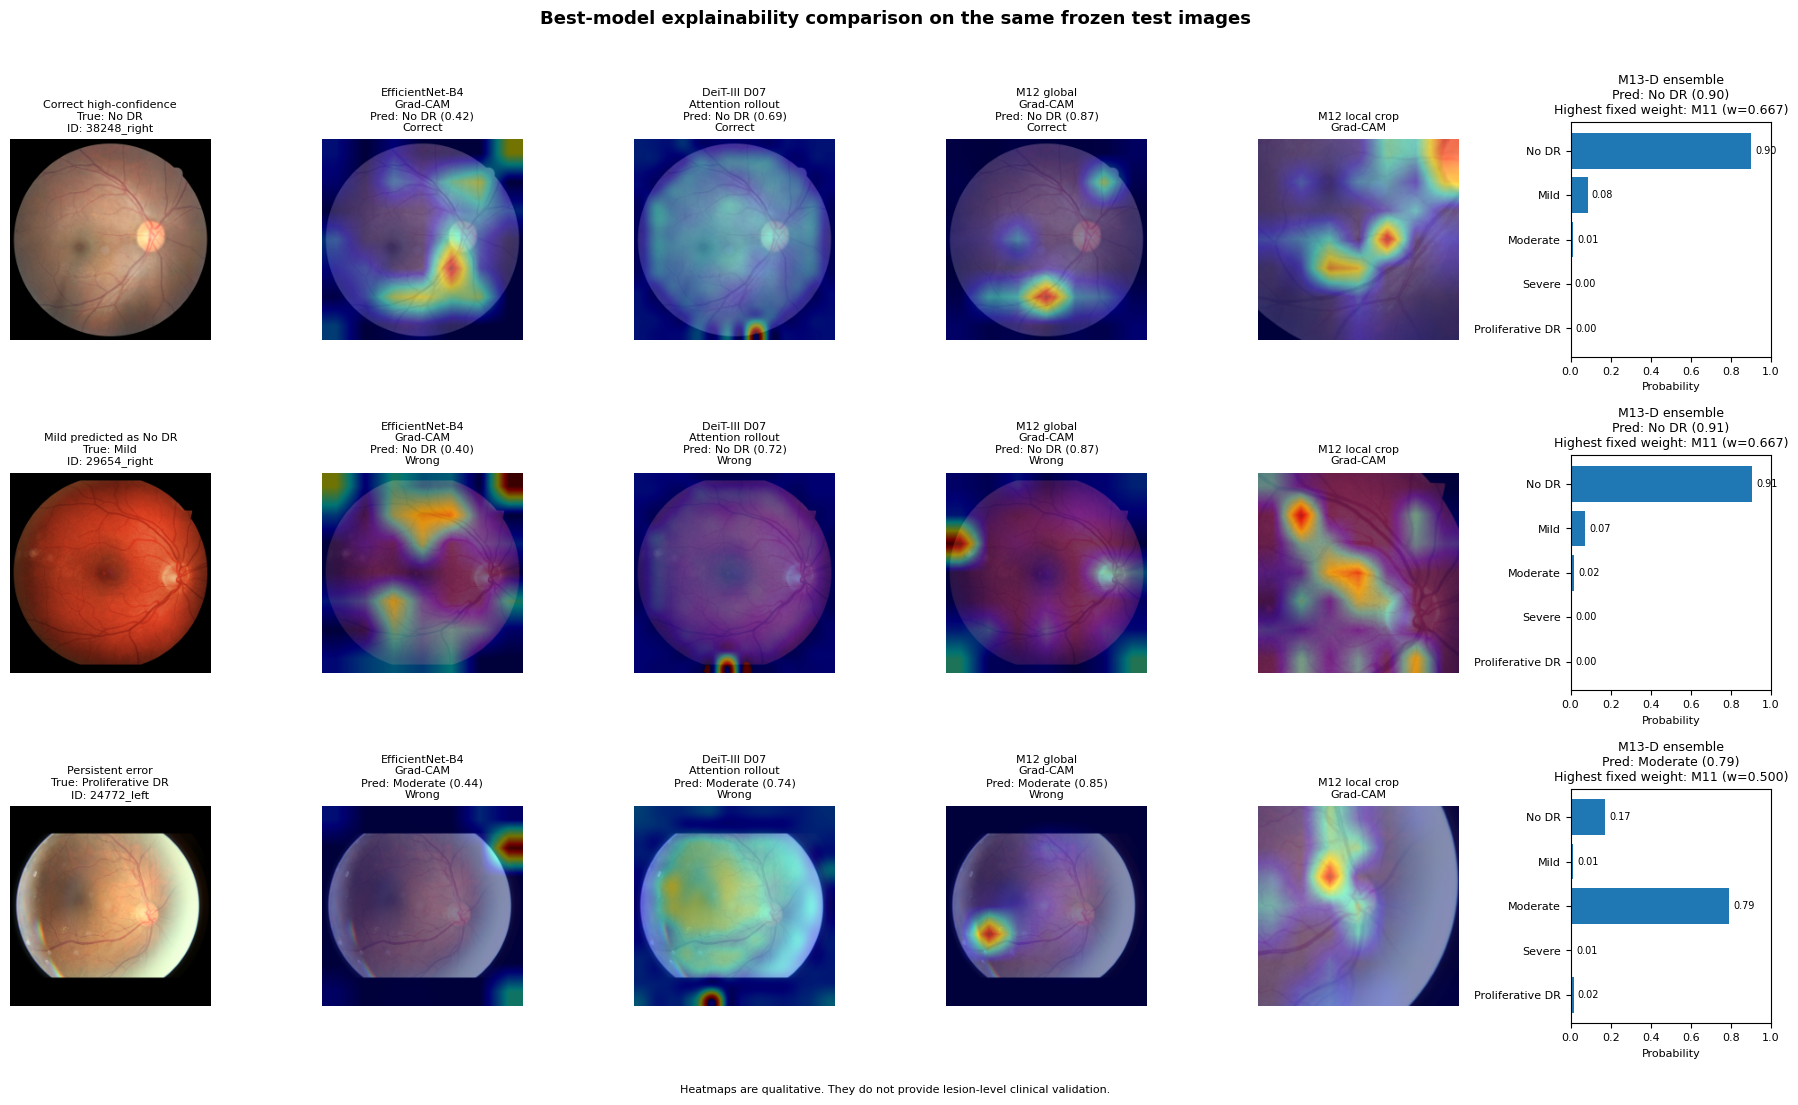

In [35]:

# Figure 8: same images across all headline systems.
# Columns: original, EfficientNet Grad-CAM, DeiT attention rollout,
# M12 global Grad-CAM, M12 local Grad-CAM, M13-D ensemble evidence.

n_cases = len(report_case_df)

fig, axes = plt.subplots(
    n_cases,
    6,
    figsize=(18, 3.6 * n_cases),
    squeeze=False,
)

test_lookup = test_df.set_index("image")

for row_index, case in report_case_df.iterrows():
    image_id = str(case["image_id"])
    image_path = test_lookup.loc[image_id, "filepath"]

    eff = get_efficientnet_explanation(image_path)
    deit = get_deit_explanation(image_path)
    m12 = compute_m12_explanation(image_path)
    m13 = get_m13_evidence(image_id)

    true_label = int(
        a01_predictions["M12"]
        .set_index("image_id")
        .loc[image_id, "true_label"]
    )

    # Original image
    axes[row_index, 0].imshow(m12["global_image"])
    axes[row_index, 0].set_title(
        f"{case['case_name']}\n"
        f"True: {CLASS_NAMES[true_label]}\n"
        f"ID: {image_id}",
        fontsize=8,
    )

    # EfficientNet Grad-CAM
    axes[row_index, 1].imshow(eff["overlay"])
    axes[row_index, 1].set_title(
        short_prediction_title(
            "EfficientNet-B4\nGrad-CAM",
            true_label,
            eff["predicted_label"],
            eff["confidence"],
        ),
        fontsize=8,
    )

    # DeiT attention rollout
    axes[row_index, 2].imshow(deit["overlay"])
    axes[row_index, 2].set_title(
        short_prediction_title(
            "DeiT-III D07\nAttention rollout",
            true_label,
            deit["predicted_label"],
            deit["confidence"],
        ),
        fontsize=8,
    )

    # M12 global Grad-CAM
    axes[row_index, 3].imshow(
        overlay_heatmap(
            m12["global_image"],
            m12["global_cam"],
        )
    )
    axes[row_index, 3].set_title(
        short_prediction_title(
            "M12 global\nGrad-CAM",
            true_label,
            m12["prediction"],
            m12["confidence"],
        ),
        fontsize=8,
    )

    # M12 local Grad-CAM
    axes[row_index, 4].imshow(
        overlay_heatmap(
            m12["local_image"],
            m12["local_cam"],
        )
    )
    axes[row_index, 4].set_title(
        "M12 local crop\nGrad-CAM",
        fontsize=8,
    )

    # M13-D evidence
    draw_m13_probability_panel(
        axes[row_index, 5],
        m13,
    )

    for column in range(5):
        axes[row_index, column].axis("off")

fig.suptitle(
    "Best-model explainability comparison on the same frozen test images",
    fontsize=13,
    fontweight="bold",
    y=1.005,
)
fig.text(
    0.5,
    0.002,
    "Heatmaps are qualitative. They do not provide lesion-level clinical validation.",
    ha="center",
    fontsize=8,
)
plt.tight_layout(rect=[0, 0.02, 1, 0.99])

save_report_figure(
    fig,
    "A02_figure_08_best_models_shared_image_comparison",
)
plt.show()


Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/A02_figure_09A_efficientnet_gradcam.png
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/A02_figure_09A_efficientnet_gradcam.pdf


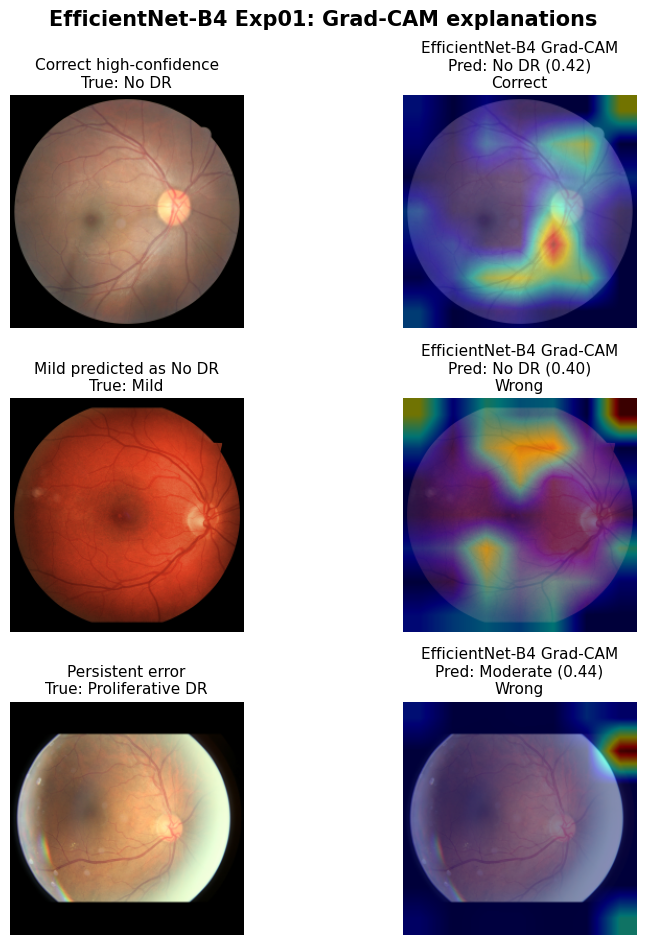

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/A02_figure_09B_deit_attention_rollout.png
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/A02_figure_09B_deit_attention_rollout.pdf


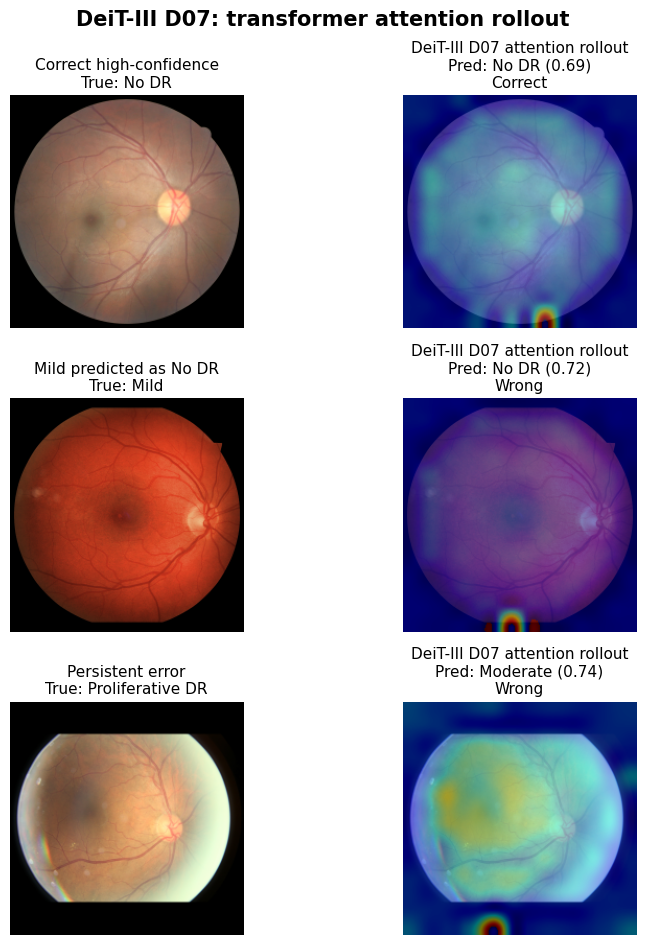

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/A02_figure_09C_m12_global_local_gradcam.png
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/analysis/A02_explainability_failure_analysis/A02_figure_09C_m12_global_local_gradcam.pdf


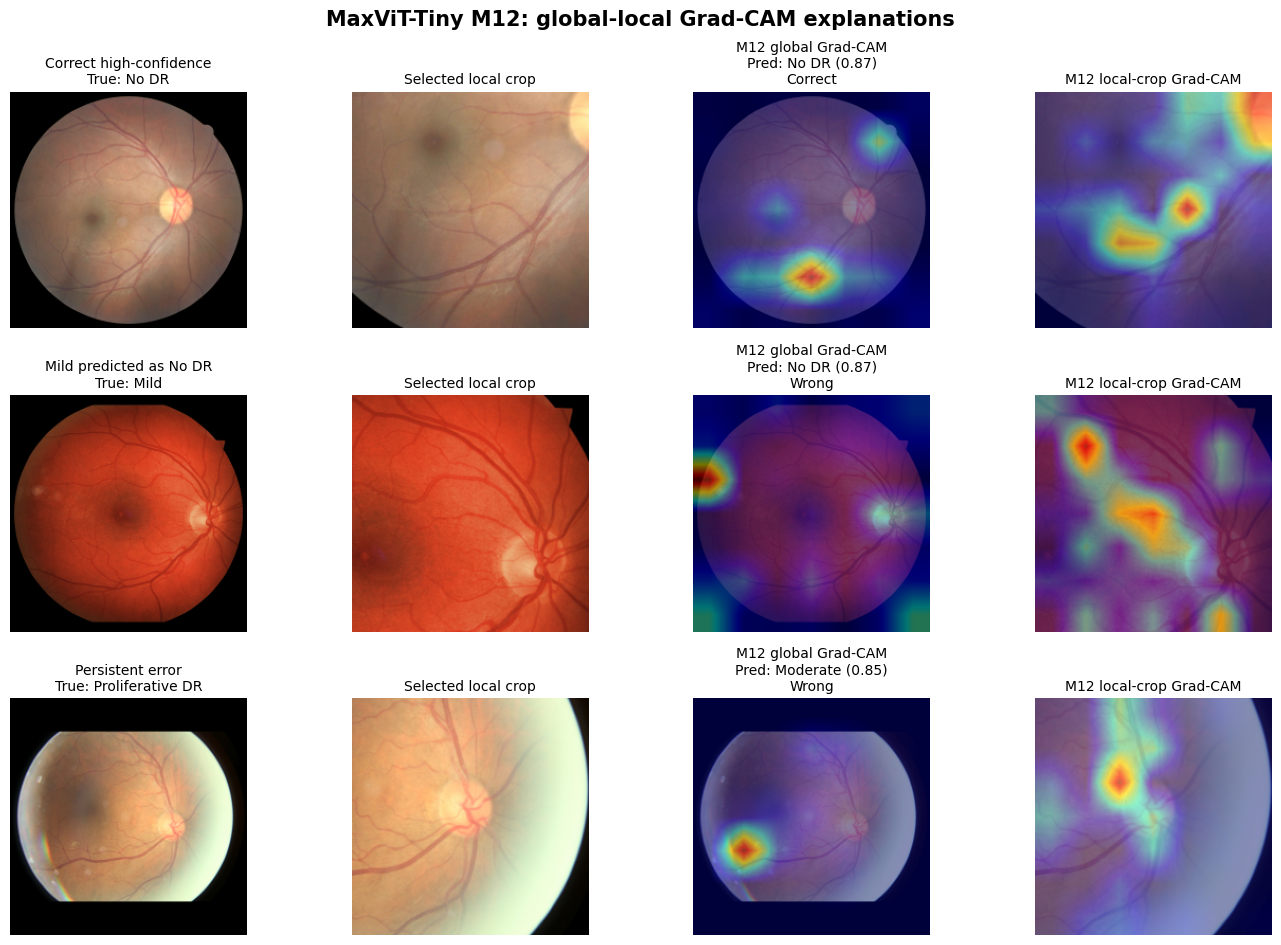

In [36]:

# Figures 9A-9C: large model-specific panels for clear report insertion.

model_figure_specs = [
    (
        "EfficientNet-B4 Exp01",
        "A02_figure_09A_efficientnet_gradcam",
    ),
    (
        "DeiT-III D07",
        "A02_figure_09B_deit_attention_rollout",
    ),
    (
        "MaxViT-Tiny M12",
        "A02_figure_09C_m12_global_local_gradcam",
    ),
]

# EfficientNet
fig, axes = plt.subplots(
    len(report_case_df),
    2,
    figsize=(9, 3.2 * len(report_case_df)),
    squeeze=False,
)

for row_index, case in report_case_df.iterrows():
    image_id = str(case["image_id"])
    image_path = test_lookup.loc[image_id, "filepath"]
    explanation = get_efficientnet_explanation(image_path)
    true_label = int(
        a01_predictions["EfficientNet-B4"]
        .set_index("image_id")
        .loc[image_id, "true_label"]
    )

    axes[row_index, 0].imshow(explanation["image"])
    axes[row_index, 0].set_title(
        f"{case['case_name']}\nTrue: {CLASS_NAMES[true_label]}",
        fontsize=11,
    )
    axes[row_index, 1].imshow(explanation["overlay"])
    axes[row_index, 1].set_title(
        short_prediction_title(
            "EfficientNet-B4 Grad-CAM",
            true_label,
            explanation["predicted_label"],
            explanation["confidence"],
        ),
        fontsize=11,
    )

    axes[row_index, 0].axis("off")
    axes[row_index, 1].axis("off")

fig.suptitle(
    "EfficientNet-B4 Exp01: Grad-CAM explanations",
    fontsize=15,
    fontweight="bold",
)
plt.tight_layout()
save_report_figure(
    fig,
    "A02_figure_09A_efficientnet_gradcam",
)
plt.show()

# DeiT
fig, axes = plt.subplots(
    len(report_case_df),
    2,
    figsize=(9, 3.2 * len(report_case_df)),
    squeeze=False,
)

for row_index, case in report_case_df.iterrows():
    image_id = str(case["image_id"])
    image_path = test_lookup.loc[image_id, "filepath"]
    explanation = get_deit_explanation(image_path)
    true_label = int(
        a01_predictions["DeiT-III"]
        .set_index("image_id")
        .loc[image_id, "true_label"]
    )

    axes[row_index, 0].imshow(explanation["image"])
    axes[row_index, 0].set_title(
        f"{case['case_name']}\nTrue: {CLASS_NAMES[true_label]}",
        fontsize=11,
    )
    axes[row_index, 1].imshow(explanation["overlay"])
    axes[row_index, 1].set_title(
        short_prediction_title(
            "DeiT-III D07 attention rollout",
            true_label,
            explanation["predicted_label"],
            explanation["confidence"],
        ),
        fontsize=11,
    )

    axes[row_index, 0].axis("off")
    axes[row_index, 1].axis("off")

fig.suptitle(
    "DeiT-III D07: transformer attention rollout",
    fontsize=15,
    fontweight="bold",
)
plt.tight_layout()
save_report_figure(
    fig,
    "A02_figure_09B_deit_attention_rollout",
)
plt.show()

# M12
fig, axes = plt.subplots(
    len(report_case_df),
    4,
    figsize=(14, 3.2 * len(report_case_df)),
    squeeze=False,
)

for row_index, case in report_case_df.iterrows():
    image_id = str(case["image_id"])
    image_path = test_lookup.loc[image_id, "filepath"]
    explanation = compute_m12_explanation(image_path)
    true_label = int(
        a01_predictions["M12"]
        .set_index("image_id")
        .loc[image_id, "true_label"]
    )

    axes[row_index, 0].imshow(explanation["global_image"])
    axes[row_index, 0].set_title(
        f"{case['case_name']}\nTrue: {CLASS_NAMES[true_label]}",
        fontsize=10,
    )
    axes[row_index, 1].imshow(explanation["local_image"])
    axes[row_index, 1].set_title(
        "Selected local crop",
        fontsize=10,
    )
    axes[row_index, 2].imshow(
        overlay_heatmap(
            explanation["global_image"],
            explanation["global_cam"],
        )
    )
    axes[row_index, 2].set_title(
        short_prediction_title(
            "M12 global Grad-CAM",
            true_label,
            explanation["prediction"],
            explanation["confidence"],
        ),
        fontsize=10,
    )
    axes[row_index, 3].imshow(
        overlay_heatmap(
            explanation["local_image"],
            explanation["local_cam"],
        )
    )
    axes[row_index, 3].set_title(
        "M12 local-crop Grad-CAM",
        fontsize=10,
    )

    for column in range(4):
        axes[row_index, column].axis("off")

fig.suptitle(
    "MaxViT-Tiny M12: global-local Grad-CAM explanations",
    fontsize=15,
    fontweight="bold",
)
plt.tight_layout()
save_report_figure(
    fig,
    "A02_figure_09C_m12_global_local_gradcam",
)
plt.show()


### M13-D duplicate figure intentionally omitted

The compact class-weight constituent figure generated in Section 6 is retained as the
single configuration-context figure. Figure 8 already presents M13-D probabilities for the
same predetermined test images.

The constituent with the largest fixed weight for the predicted class is not a per-image
attribution. No artificial ensemble Grad-CAM is created.


### How these figures support the report discussion

Use the figures to compare model behaviour on identical frozen test images:

- **EfficientNet-B4:** discuss whether Grad-CAM sensitivity is concentrated or spatially
  broad, while avoiding clinical lesion claims.
- **DeiT-III:** discuss whether attention rollout is more spatially distributed and whether
  it captures wider retinal context.
- **M12:** compare global and local branch sensitivity and whether both branches attend to
  similar or different retinal regions.
- **M13-D:** discuss its class-probability distribution. The highest-weighted constituent is
  fixed by predicted class and must not be described as a per-image causal contribution.

Use cautious wording such as:

> The highlighted region may have influenced the prediction. The visualisation is
> qualitative and does not provide lesion-level clinical validation.


In [37]:
from IPython.display import Markdown, display

# ---------------------------------------------------------------------
# Load final A01 metrics and identify the QWK-best model
# ---------------------------------------------------------------------
final_metrics_df = pd.read_csv(
    A01_LOG_DIR / "final_test_metrics.csv"
)

best_qwk_model = (
    final_metrics_df
    .sort_values("qwk", ascending=False)
    .iloc[0]["model"]
)

# ---------------------------------------------------------------------
# Calculate M12 error counts directly from its frozen A01 predictions
# ---------------------------------------------------------------------
m12_summary_df = a01_predictions["M12"].copy()

required_columns = {
    "true_label",
    "predicted_label",
}

missing_columns = required_columns.difference(
    m12_summary_df.columns
)

if missing_columns:
    raise KeyError(
        "M12 prediction table is missing required columns: "
        f"{sorted(missing_columns)}"
    )

m12_true = (
    m12_summary_df["true_label"]
    .to_numpy(dtype=int)
)

m12_pred = (
    m12_summary_df["predicted_label"]
    .to_numpy(dtype=int)
)

m12_under_grading_count = int(
    np.sum(m12_pred < m12_true)
)

m12_over_grading_count = int(
    np.sum(m12_pred > m12_true)
)

m12_correct_count = int(
    np.sum(m12_pred == m12_true)
)

m12_one_grade_error_count = int(
    np.sum(
        np.abs(m12_pred - m12_true) == 1
    )
)

m12_two_or_more_grade_error_count = int(
    np.sum(
        np.abs(m12_pred - m12_true) >= 2
    )
)

# ---------------------------------------------------------------------
# Count M13-D corrections and newly introduced errors
# ---------------------------------------------------------------------
transition_counts = (
    m12_m13_transition_examples_df[
        "transition_type"
    ]
    .value_counts()
    .to_dict()
)

corrected_count = int(
    transition_counts.get(
        "corrected_by_m13",
        0,
    )
)

introduced_count = int(
    transition_counts.get(
        "introduced_by_m13",
        0,
    )
)

# ---------------------------------------------------------------------
# Identify the weakest stable M12 subgroup
# ---------------------------------------------------------------------
stable_m12_subgroups = (
    subgroup_performance_a02_df[
        (
            subgroup_performance_a02_df["model"]
            == "M12"
        )
        & (
            subgroup_performance_a02_df[
                "qwk_stable"
            ]
        )
        & (
            subgroup_performance_a02_df[
                "qwk"
            ].notna()
        )
    ]
)

if len(stable_m12_subgroups) > 0:
    weakest = (
        stable_m12_subgroups
        .sort_values("qwk")
        .iloc[0]
    )

    weakest_text = (
        f"{weakest['subgroup_type']}="
        f"{weakest['subgroup_value']} "
        f"(n={int(weakest['n'])}, "
        f"QWK={float(weakest['qwk']):.3f})"
    )
else:
    weakest_text = (
        "No subgroup had a stable QWK estimate."
    )

# ---------------------------------------------------------------------
# Summarise attention to borders and corners
# ---------------------------------------------------------------------
if (
    len(artefact_review_df) > 0
    and "attention_on_border"
    in artefact_review_df.columns
):
    border_mean = float(
        artefact_review_df[
            "attention_on_border"
        ].mean()
    )
else:
    border_mean = np.nan

if (
    len(artefact_review_df) > 0
    and "attention_on_corner"
    in artefact_review_df.columns
):
    corner_mean = float(
        artefact_review_df[
            "attention_on_corner"
        ].mean()
    )
else:
    corner_mean = np.nan

border_text = (
    f"{border_mean:.3f}"
    if np.isfinite(border_mean)
    else "not available"
)

corner_text = (
    f"{corner_mean:.3f}"
    if np.isfinite(corner_mean)
    else "not available"
)

# ---------------------------------------------------------------------
# Generate the final evidence-based summary
# ---------------------------------------------------------------------
summary_text = f"""
## 11. Final evidence-based summary

- **Primary model:** A01 retained **{best_qwk_model}** under the
  predefined QWK-first model-selection hierarchy.

- **M12 test predictions:** M12 produced
  **{m12_correct_count}** correct predictions,
  **{m12_under_grading_count}** under-grades, and
  **{m12_over_grading_count}** over-grades.

- **Ordinal error severity:** M12 produced
  **{m12_one_grade_error_count}** errors spanning one severity grade
  and **{m12_two_or_more_grade_error_count}** errors spanning two or
  more severity grades.

- **M13-D complementarity:** M13-D corrected
  **{corrected_count}** M12 errors and introduced
  **{introduced_count}** new errors on the frozen test set.
  M13-D does not have one valid ensemble Grad-CAM; its visual
  interpretation instead reports the constituent with the largest
  fixed weight for the predicted class. This is not a per-image
  contribution analysis.

- **Artefact attention:** Mean relative M12 global-branch attention
  was **{border_text}** at image borders and
  **{corner_text}** in image corners. A value of 1.0 represents
  the mean attention across the complete explanation map.
  These measurements remain qualitative and require manual review.

- **Weakest stable subgroup:** {weakest_text}.

- **Cross-model interpretation:** EfficientNet-B4 is interpreted
  using Grad-CAM, DeiT-III using transformer attention rollout,
  and M12 using separate global-branch and local-branch Grad-CAM
  maps. These methods should be compared on the same predetermined
  test images so that differences in model behaviour can be
  discussed consistently.

- **Interpretability limitation:** Grad-CAM and attention rollout
  are qualitative sensitivity or attention visualisations. They
  are not causal explanations, clinical lesion localisation, or
  proof that a highlighted area corresponds to a specific retinal
  abnormality. Expert lesion-level annotations were not available
  for validation.

- **A01 consistency:** M12 remains the primary final model because
  it achieved the highest QWK. M13-D remains a complementary
  ensemble with slightly better macro-F1 and calibration, but lower
  QWK and substantially greater computational complexity.
"""

display(
    Markdown(summary_text)
)

summary_path = (
    A02_LOG_DIR
    / "final_summary.md"
)

summary_path.write_text(
    summary_text,
    encoding="utf-8",
)

print(
    f"Saved -> {summary_path}"
)


## 11. Final evidence-based summary

- **Primary model:** A01 retained **M12** under the
  predefined QWK-first model-selection hierarchy.

- **M12 test predictions:** M12 produced
  **4333** correct predictions,
  **613** under-grades, and
  **324** over-grades.

- **Ordinal error severity:** M12 produced
  **644** errors spanning one severity grade
  and **293** errors spanning two or
  more severity grades.

- **M13-D complementarity:** M13-D corrected
  **203** M12 errors and introduced
  **127** new errors on the frozen test set.
  M13-D does not have one valid ensemble Grad-CAM; its visual
  interpretation instead reports the constituent with the largest
  fixed weight for the predicted class. This is not a per-image
  contribution analysis.

- **Artefact attention:** Mean relative M12 global-branch attention
  was **0.652** at image borders and
  **1.304** in image corners. A value of 1.0 represents
  the mean attention across the complete explanation map.
  These measurements remain qualitative and require manual review.

- **Weakest stable subgroup:** eye=left (n=2635, QWK=0.774).

- **Cross-model interpretation:** EfficientNet-B4 is interpreted
  using Grad-CAM, DeiT-III using transformer attention rollout,
  and M12 using separate global-branch and local-branch Grad-CAM
  maps. These methods should be compared on the same predetermined
  test images so that differences in model behaviour can be
  discussed consistently.

- **Interpretability limitation:** Grad-CAM and attention rollout
  are qualitative sensitivity or attention visualisations. They
  are not causal explanations, clinical lesion localisation, or
  proof that a highlighted area corresponds to a specific retinal
  abnormality. Expert lesion-level annotations were not available
  for validation.

- **A01 consistency:** M12 remains the primary final model because
  it achieved the highest QWK. M13-D remains a complementary
  ensemble with slightly better macro-F1 and calibration, but lower
  QWK and substantially greater computational complexity.


Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/analysis/A02_explainability_failure_analysis/final_summary.md
